# Drug Repurposing Case
This code got all the outputs for the drug repurposing case.

# DEPICT Figure 4 — focused analysis of MRE-269 and benzethonium

This notebook re-runs the Figure 4 repurposing-hypothesis analysis using two manually specified DEPICT-prioritized candidates: **MRE-269** and **benzethonium**. The candidate set is intentionally fixed after the initial DEPICT top-50 and observed-A549-screen exclusion logic, because literature review indicates that MRE-269 is FDA-approved for pulmonary arterial hypertension (PAH), while benzethonium remains the other candidate of interest from the current DEPICT-only analysis.

Each code block begins with a short markdown explanation of what it does.


## 1. Imports, output folders, and analysis constants

This block imports the required packages, defines the project/output folders, and sets the filtering and plotting constants. Edit `PROJECT_DIR` only if your files are in a different location.


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

# ---------------------------------------------------------------------
# Main project folder. Adjust this if your files are elsewhere.
# ---------------------------------------------------------------------
PROJECT_DIR = Path("/work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening")

# Where outputs from this notebook will be written.
OUT_DIR = PROJECT_DIR / "Figure4_MRE269_Benzethonium_repurposing"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Candidate rule for this run.
# Focused manual-candidate analysis:
# 1) start from DEPICT-predicted top 50,
# 2) remove drugs present in the observed A549 NSCLC screening universe,
# 3) keep only the two prespecified candidates below.
# FDA/NSCLC approval status is retained as annotation only, with MRE-269 manually noted
# as FDA-approved for pulmonary arterial hypertension (PAH) based on follow-up review.
PRIMARY_TOP_N = 50
SELECTED_CANDIDATE_NAMES = ["MRE-269", "benzethonium"]
SELECTION_LABEL = "mre269_benzethonium_top50_depict_only"

# Main Figure 4B reference rule.
REFERENCE_REQUIRE_POSITIVE_OBSERVED_SCORE = True
MIN_REFERENCE_DRUGS = 3
REFERENCE_FALLBACK_TOP_N = 200

# Pathway scoring options, aligned with the Figure 3 notebook.
MIN_LANDMARK_OVERLAP = 10
GSEA_WEIGHT_EXPONENT = 1.0
NSCLC_SIGNATURE_IS_ALREADY_REVERSED = False  # keep False if signature is tumor-vs-normal log2FC

# Readiness summary thresholds. These are intentionally configurable.
PATHWAY_BREADTH_THRESHOLD = 0.0
HIGH_SIMILARITY_RHO = 0.30
HIGH_COMPLEMENTARITY_N = 2

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

print("PROJECT_DIR:", PROJECT_DIR)
print("OUT_DIR:", OUT_DIR)


PROJECT_DIR: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening
OUT_DIR: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing


## 2. File discovery

This block searches for the score tables, DGE tables, NSCLC signature, Hallmark GMT file, Drug Repurposing Hub metadata, and the curated FDA-approved NSCLC synonym table. If any path is missing, edit the corresponding `resolved[...]` line manually.


In [2]:
FILE_CANDIDATES = {
    "FINAL_DF_PRED_PATH": [
        "reverseScore_predicted_All.csv",
    ],
    "FINAL_DF_ORIG_PATH": [
        "reverseScore_observed_All.csv",
    ],
    "DF_DIFFEXP_PRED_PATH": [
        "diff_geneExp_pred.csv",
    ],
    "DF_DIFFEXP_OBS_PATH": [
        "diff_geneExp_meanPlate.csv",
    ],
    "NSCLC_SIGNATURE_PATH": [
        "E-GEOD-18842-A-AFFY-44-analytics.tsv",
    ],
    "HALLMARK_GMT_PATH": [
        "h.all.v2026.1.Hs.symbols.gmt.txt",
    ],
    "FDA_NSCLC_SYNONYM_PATH": [
        "fda_approved_nsclc_synonym_table.csv",
    ],
    "DRUG_META_PATH": [
        "repurposing_drugs_20200324.txt",
    ],
}


def resolve_file(candidate_names, project_dir=PROJECT_DIR, extra_dirs=None, recursive=True):
    extra_dirs = extra_dirs or []
    search_roots = [
        project_dir,
        project_dir / "data",
        project_dir / "Data",
        project_dir / "tables",
        project_dir / "Tables",
        project_dir.parent,
    ] + [Path(x) for x in extra_dirs]
    for root in search_roots:
        for name in candidate_names:
            p = root / name
            if p.exists():
                return p
    if recursive:
        for name in candidate_names:
            hits = list(project_dir.rglob(name))
            if hits:
                return hits[0]
            parent_hits = list(project_dir.parent.rglob(name)) if project_dir.parent.exists() else []
            if parent_hits:
                return parent_hits[0]
    return None


resolved = {key: resolve_file(names) for key, names in FILE_CANDIDATES.items()}
for key, path in resolved.items():
    print(f"{key}: {path}")

# Manual overrides can be placed here if needed. Example:
# resolved["DRUG_META_PATH"] = PROJECT_DIR / "data" / "repurposing_drugs_20200324.txt"

missing = [k for k, v in resolved.items() if v is None or not Path(v).exists()]
if missing:
    print("\nMissing required files:", missing)
    print("Please edit `resolved[...]` above before running downstream cells.")
else:
    print("\nAll required files found.")

FINAL_DF_PRED_PATH = resolved["FINAL_DF_PRED_PATH"]
FINAL_DF_ORIG_PATH = resolved["FINAL_DF_ORIG_PATH"]
DF_DIFFEXP_PRED_PATH = resolved["DF_DIFFEXP_PRED_PATH"]
DF_DIFFEXP_OBS_PATH = resolved["DF_DIFFEXP_OBS_PATH"]
NSCLC_SIGNATURE_PATH = resolved["NSCLC_SIGNATURE_PATH"]
HALLMARK_GMT_PATH = resolved["HALLMARK_GMT_PATH"]
FDA_NSCLC_SYNONYM_PATH = resolved["FDA_NSCLC_SYNONYM_PATH"]
DRUG_META_PATH = resolved["DRUG_META_PATH"]


FINAL_DF_PRED_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/reverseScore_predicted_All.csv
FINAL_DF_ORIG_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/reverseScore_observed_All.csv
DF_DIFFEXP_PRED_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/diff_geneExp_pred.csv
DF_DIFFEXP_OBS_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/diff_geneExp_meanPlate.csv
NSCLC_SIGNATURE_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/data/E-GEOD-18842-A-AFFY-44-analytics.tsv
HALLMARK_GMT_PATH: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Ju

## 3. General helper functions

This block defines reusable functions for name normalization, safe file reading, figure saving, ranking, synonym expansion, similarity calculation, and DGE-profile attachment.


In [3]:
def normalize_drug_name(x):
    """Normalize drug names for robust matching across LINCS, Drug Repurposing Hub, and FDA synonyms."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = x.replace("–", "-").replace("—", "-").replace("−", "-")
    x = re.sub(r"\([^)]*\)", "", x)
    x = re.sub(r"[^a-z0-9]+", "", x)
    aliases = {
        "nvpbez235": "dactolisib",
        "bez235": "dactolisib",
        "gsk2126458": "omipalisib",
        "gdc0941": "pictilisib",
        "mepacrine": "quinacrine",
        "nabpaclitaxel": "paclitaxelalbuminstabilizednanoparticleformulation",
        "abraxane": "paclitaxelalbuminstabilizednanoparticleformulation",
        "taxol": "paclitaxel",
        "taxotere": "docetaxel",
        "alimta": "pemetrexed",
        "gemzar": "gemcitabine",
        "tarceva": "erlotinib",
        "iressa": "gefitinib",
        "xalkori": "crizotinib",
        "tagrisso": "osimertinib",
        "azd9291": "osimertinib",
        "osi774": "erlotinib",
        "pf02341066": "crizotinib",
        "amg510": "sotorasib",
        "mrtx849": "adagrasib",
        "rad001": "everolimus",
    }
    return aliases.get(x, x)


def read_table_auto(path, **kwargs):
    path = Path(path)
    if path.suffix.lower() in [".tsv", ".txt"]:
        df = pd.read_csv(path, sep="\t", **kwargs)
    else:
        df = pd.read_csv(path, **kwargs)
    unnamed = [c for c in df.columns if str(c).startswith("Unnamed:")]
    if unnamed:
        df = df.drop(columns=unnamed)
    return df


def save_figure(fig, stem, show=True):
    for ext in ["pdf", "png", "svg"]:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def show_df(df, title=None, n=20):
    if title:
        print(f"\n{title}")
        print("-" * len(title))
    display(df.head(n))
    print("shape:", df.shape)


def pick_score_column(df):
    for col in ["reverse_score", "ranking_score", "score", "RS", "connectivity_reverse_score"]:
        if col in df.columns:
            return col
    raise ValueError(f"Could not find score column in: {df.columns.tolist()}")


def best_per_drug(df, source_label):
    if "pert_iname" not in df.columns:
        raise ValueError("Expected a `pert_iname` column.")
    score_col = pick_score_column(df)
    out = df.copy()
    if score_col != "reverse_score":
        out = out.rename(columns={score_col: "reverse_score"})
    out["drug_key"] = out["pert_iname"].map(normalize_drug_name)
    out = out.dropna(subset=["drug_key"])
    out["reverse_score"] = pd.to_numeric(out["reverse_score"], errors="coerce")
    out = out.sort_values(["drug_key", "reverse_score"], ascending=[True, False])
    out = out.drop_duplicates("drug_key", keep="first")
    out = out.sort_values("reverse_score", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    out["source"] = source_label
    return out


def expand_fda_nsclc_synonyms(fda_table):
    records = []
    for _, row in fda_table.iterrows():
        terms = [row.get("canonical_name", np.nan)]
        syn = row.get("synonyms", "")
        if pd.notna(syn):
            terms += re.split(r"[;|,]", str(syn))
        for term in terms:
            term = str(term).strip()
            if not term or term.lower() == "nan":
                continue
            rec = row.to_dict()
            rec["match_term"] = term
            rec["drug_key"] = normalize_drug_name(term)
            records.append(rec)
    expanded = pd.DataFrame(records).dropna(subset=["drug_key"]).drop_duplicates(["canonical_name", "drug_key"])
    return expanded


def spearman_pair(x, y):
    a = pd.Series(x, dtype="float64")
    b = pd.Series(y, dtype="float64")
    mask = a.notna() & b.notna()
    if mask.sum() < 3:
        return np.nan, np.nan, int(mask.sum())
    rho, p = spearmanr(a[mask], b[mask])
    return float(rho), float(p), int(mask.sum())


def pearson_pair(x, y):
    a = pd.Series(x, dtype="float64")
    b = pd.Series(y, dtype="float64")
    mask = a.notna() & b.notna()
    if mask.sum() < 3:
        return np.nan, int(mask.sum())
    return float(np.corrcoef(a[mask], b[mask])[0, 1]), int(mask.sum())


def attach_dge_profiles(selected_rows, dge_df, source_label, gene_cols):
    """Attach one DGE row per selected drug from a source-specific DGE table."""
    dge = dge_df.copy()
    dge["drug_key"] = dge["pert_iname"].map(normalize_drug_name)
    if "reverse_score" in dge.columns:
        dge["reverse_score_for_match"] = pd.to_numeric(dge["reverse_score"], errors="coerce")
    else:
        dge["reverse_score_for_match"] = np.nan

    rows = []
    selected_source = selected_rows[selected_rows["source"] == source_label].copy()
    for _, srow in selected_source.iterrows():
        key = srow["drug_key"]
        sub = dge[dge["drug_key"] == key].copy()
        if sub.empty:
            rec = srow.to_dict()
            rec.update({g: np.nan for g in gene_cols})
            rec["matched_dge_strategy"] = "missing"
            rec["n_matching_dge_rows"] = 0
            rows.append(rec)
            continue
        sub = sub.sort_values("reverse_score_for_match", ascending=False, na_position="last")
        drow = sub.iloc[0]
        rec = srow.to_dict()
        for g in gene_cols:
            rec[g] = drow.get(g, np.nan)
        rec["matched_dge_strategy"] = "best_reverse_score_row" if "reverse_score" in dge.columns else "first_matching_row"
        rec["n_matching_dge_rows"] = len(sub)
        rows.append(rec)
    return pd.DataFrame(rows)


def split_targets(x):
    if pd.isna(x):
        return []
    parts = re.split(r"[;,|/]", str(x))
    genes = []
    for p in parts:
        p = p.strip()
        if not p or p.lower() in {"nan", "unknown", "not found", "na", "n/a"}:
            continue
        # Keep simple HGNC-like symbols only; remove parenthetical notes.
        p = re.sub(r"\([^)]*\)", "", p).strip()
        p = re.sub(r"[^A-Za-z0-9\-]", "", p).upper()
        if p:
            genes.append(p)
    return sorted(set(genes))


## 4. Load ranking tables, Drug Repurposing Hub metadata, and FDA-approved NSCLC synonyms

This block loads the predicted and observed NSCLC screening rankings, reduces each table to one best row per drug, and loads the two clinical annotation resources used for FDA approval and NSCLC-approved exclusion.


In [4]:
final_df_pred = read_table_auto(FINAL_DF_PRED_PATH)
final_df_orig = read_table_auto(FINAL_DF_ORIG_PATH)
drug_meta = pd.read_csv(DRUG_META_PATH, sep="\t", skiprows=9)
fda_nsclc_table = read_table_auto(FDA_NSCLC_SYNONYM_PATH)

pred_ranked_all = best_per_drug(final_df_pred, "DEPICT-predicted LINCS")
orig_ranked_all = best_per_drug(final_df_orig, "Observed LINCS")

# Normalize Drug Repurposing Hub metadata.
drug_meta = drug_meta.copy()
if "pert_iname" not in drug_meta.columns:
    possible_name_cols = [c for c in drug_meta.columns if c.lower() in {"name", "drug", "compound", "pert_name", "broad_id"}]
    if possible_name_cols:
        drug_meta = drug_meta.rename(columns={possible_name_cols[0]: "pert_iname"})
    else:
        raise ValueError("Drug metadata must contain `pert_iname` or a recognizable drug-name column.")
drug_meta["drug_key"] = drug_meta["pert_iname"].map(normalize_drug_name)

# FDA-approved for any disease: Broad Drug Repurposing Hub usually uses clinical_phase == Launched.
if "clinical_phase" not in drug_meta.columns:
    raise ValueError("Drug metadata must contain `clinical_phase` for FDA approval annotation.")
drug_meta["clinical_phase_clean"] = drug_meta["clinical_phase"].astype(str).str.strip()
drug_meta["fda_approved_any_disease"] = drug_meta["clinical_phase_clean"].str.lower().isin({"launched", "approved", "fda approved", "fda-approved"})

fda_nsclc_expanded = expand_fda_nsclc_synonyms(fda_nsclc_table)
nsclc_fda_keys = set(fda_nsclc_expanded["drug_key"].dropna())

# Save normalized resources.
pred_ranked_all.to_csv(TABLE_DIR / "fig4_predicted_ranking_best_per_drug.csv", index=False)
orig_ranked_all.to_csv(TABLE_DIR / "fig4_observed_ranking_best_per_drug.csv", index=False)
drug_meta.to_csv(TABLE_DIR / "fig4_drug_repurposing_hub_metadata_normalized.csv", index=False)
fda_nsclc_expanded.to_csv(TABLE_DIR / "fig4_fda_nsclc_synonym_table_expanded.csv", index=False)

print("pred_ranked_all:", pred_ranked_all.shape)
print("orig_ranked_all:", orig_ranked_all.shape)
print("drug_meta:", drug_meta.shape)
print("FDA-approved-for-any-disease drugs in metadata:", int(drug_meta["fda_approved_any_disease"].sum()))
print("FDA-approved NSCLC synonym keys:", len(nsclc_fda_keys))
show_df(drug_meta[["pert_iname", "clinical_phase", "fda_approved_any_disease"] + (["target"] if "target" in drug_meta.columns else [])], "Drug metadata preview", 10)
show_df(fda_nsclc_expanded[["canonical_name", "match_term", "drug_key", "approval_type"]], "Expanded FDA-approved NSCLC synonym preview", 20)


pred_ranked_all: (17194, 8)
orig_ranked_all: (11779, 8)
drug_meta: (6798, 9)
FDA-approved-for-any-disease drugs in metadata: 2427
FDA-approved NSCLC synonym keys: 179

Drug metadata preview
---------------------


,pert_iname,clinical_phase,fda_approved_any_disease,target
0,(R)-(-)-apomorphine,Launched,True,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...
1,(R)-(-)-rolipram,Phase 1,False,PDE4A|PDE4B|PDE4C|PDE4D|PDE5A
2,(R)-baclofen,Phase 3,False,GABBR1|GABBR2
3,(S)-(+)-rolipram,Phase 1,False,PDE4B|PDE4D
4,"[sar9,met(o2)11]-substance-p",Preclinical,False,TACR1
5,A-1070722,Preclinical,False,GSK3A|GSK3B
6,A-1120,Preclinical,False,RBP4
7,A-317491,Preclinical,False,P2RX3
8,A-33903,Phase 2,False,NaN
9,A-366,Preclinical,False,EHMT1|EHMT2


shape: (6798, 4)

Expanded FDA-approved NSCLC synonym preview
-------------------------------------------


,canonical_name,match_term,drug_key,approval_type
0,crizotinib,crizotinib,crizotinib,single-agent approved
4,alectinib,alectinib,alectinib,single-agent approved
6,alectinib,Alecensa,alecensa,single-agent approved
7,alectinib,CH5424802,ch5424802,single-agent approved
8,alectinib,RO5424802,ro5424802,single-agent approved
9,brigatinib,brigatinib,brigatinib,single-agent approved
11,brigatinib,Alunbrig,alunbrig,single-agent approved
12,brigatinib,AP26113,ap26113,single-agent approved
13,ceritinib,ceritinib,ceritinib,single-agent approved
15,ceritinib,Zykadia,zykadia,single-agent approved


shape: (179, 4)


## 5. Candidate selection rule and candidate-count table

This block applies the DEPICT top-50 and observed-A549-screen exclusion rule, then keeps MRE-269 and benzethonium as the focused case-study candidates. The candidate counts are retained as a table for reporting in the Results text; the former number-funnel figure has been removed from the final Figure 4 layout.


In [5]:
observed_a549_keys = set(orig_ranked_all["drug_key"].dropna())

# Merge Drug Repurposing Hub clinical/target annotations.
# These fields are annotation-only in this version; they are not used for candidate filtering.
meta_cols = ["drug_key", "pert_iname", "clinical_phase", "clinical_phase_clean", "fda_approved_any_disease"]
for extra in ["target", "moa", "disease_area", "indication", "mechanism_of_action"]:
    if extra in drug_meta.columns and extra not in meta_cols:
        meta_cols.append(extra)
meta_for_merge = drug_meta[meta_cols].drop_duplicates("drug_key").copy()
meta_for_merge = meta_for_merge.rename(columns={"pert_iname": "drug_meta_name"})

pred_annot = pred_ranked_all.merge(meta_for_merge, on="drug_key", how="left")
pred_annot["observed_screening_present"] = pred_annot["drug_key"].isin(observed_a549_keys)
pred_annot["nsclc_approved_fda"] = pred_annot["drug_key"].isin(nsclc_fda_keys)
pred_annot["in_depict_topN"] = pred_annot["rank"] <= PRIMARY_TOP_N

# Candidate pool after the relaxed top-50 DEPICT-only rule.
top50_depict_only_pool = pred_annot[
    (pred_annot["in_depict_topN"])
    & (~pred_annot["observed_screening_present"])
].copy()
top50_depict_only_pool = top50_depict_only_pool.sort_values("rank").reset_index(drop=True)

# Resolve the manually specified candidate names robustly.
# Exact normalized-name matching is preferred; contains matching is used only as a fallback
# for cases such as "benzethonium" versus "benzethonium chloride".
def resolve_candidate_keys(candidate_names, pool):
    records = []
    pool = pool.copy()
    pool["_name_lower"] = pool["pert_iname"].astype(str).str.lower()
    for raw_name in candidate_names:
        key = normalize_drug_name(raw_name)
        exact = pool[pool["drug_key"] == key].copy()
        if exact.empty:
            raw_lower = str(raw_name).lower().strip()
            contains = pool[
                pool["_name_lower"].str.contains(re.escape(raw_lower), na=False)
                | pd.Series([raw_lower in str(x).lower() for x in pool["pert_iname"]], index=pool.index)
            ].copy()
            matched = contains
            match_type = "contains_fallback"
        else:
            matched = exact
            match_type = "exact_normalized"
        if matched.empty:
            records.append({
                "requested_name": raw_name,
                "matched": False,
                "match_type": "not_found_in_top50_depict_only_pool",
                "matched_pert_iname": np.nan,
                "drug_key": key,
                "rank": np.nan,
            })
        else:
            for _, row in matched.iterrows():
                records.append({
                    "requested_name": raw_name,
                    "matched": True,
                    "match_type": match_type,
                    "matched_pert_iname": row["pert_iname"],
                    "drug_key": row["drug_key"],
                    "rank": row["rank"],
                })
    return pd.DataFrame(records)

manual_match_audit = resolve_candidate_keys(SELECTED_CANDIDATE_NAMES, top50_depict_only_pool)
matched_keys = set(manual_match_audit.loc[manual_match_audit["matched"], "drug_key"].dropna())

primary_candidates = top50_depict_only_pool[top50_depict_only_pool["drug_key"].isin(matched_keys)].copy()
primary_candidates = primary_candidates.sort_values("rank").drop_duplicates("drug_key").reset_index(drop=True)
primary_candidates["candidate_set"] = SELECTION_LABEL

# Manual annotation for this focused run.
primary_candidates["manual_literature_annotation"] = ""
primary_candidates.loc[
    primary_candidates["drug_key"].eq(normalize_drug_name("MRE-269")),
    "manual_literature_annotation",
] = "MRE-269 manually treated as FDA-approved for pulmonary arterial hypertension (PAH) for this focused repurposing analysis."

# Do not override the raw Drug Repurposing Hub clinical_phase value, but add a focused-run flag.
primary_candidates["focused_candidate_selected"] = True
primary_candidates["selected_candidate_name_requested"] = primary_candidates["drug_key"].map(
    dict(zip(manual_match_audit.loc[manual_match_audit["matched"], "drug_key"],
             manual_match_audit.loc[manual_match_audit["matched"], "requested_name"]))
)

# Funnel counts for the focused candidate rule.
funnel_steps = []
funnel_steps.append({"step": "All screened DEPICT compounds", "n_drugs": pred_ranked_all["drug_key"].nunique()})
funnel_steps.append({"step": f"DEPICT top {PRIMARY_TOP_N}", "n_drugs": pred_annot.loc[pred_annot["rank"] <= PRIMARY_TOP_N, "drug_key"].nunique()})
funnel_steps.append({
    "step": "Remove drugs present in observed A549 screen",
    "n_drugs": top50_depict_only_pool["drug_key"].nunique(),
})
funnel_steps.append({
    "step": "Keep prespecified candidates: MRE-269 and benzethonium",
    "n_drugs": primary_candidates["drug_key"].nunique(),
})
funnel_df = pd.DataFrame(funnel_steps)
funnel_df["step_order"] = np.arange(1, len(funnel_df) + 1)

pred_annot.to_csv(TABLE_DIR / "fig4_predicted_top_drug_filter_audit_all_drugs.csv", index=False)
top50_depict_only_pool.to_csv(TABLE_DIR / "fig4_top50_depict_only_candidate_pool_before_manual_selection.csv", index=False)
manual_match_audit.to_csv(TABLE_DIR / "fig4_manual_candidate_match_audit_mre269_benzethonium.csv", index=False)
primary_candidates.to_csv(TABLE_DIR / "fig4_primary_mre269_benzethonium_candidates.csv", index=False)
funnel_df.to_csv(TABLE_DIR / "fig4a_candidate_selection_funnel_counts.csv", index=False)

annotation_cols = [
    "pert_iname", "rank", "reverse_score", "clinical_phase", "fda_approved_any_disease",
    "nsclc_approved_fda", "observed_screening_present", "moa", "target", "disease_area", "indication",
    "manual_literature_annotation",
]
annotation_cols = [c for c in annotation_cols if c in primary_candidates.columns]

show_df(funnel_df, "Figure 4A funnel counts", 10)
show_df(manual_match_audit, "Manual candidate matching audit", 20)
show_df(top50_depict_only_pool[[c for c in ["pert_iname", "rank", "reverse_score", "clinical_phase", "fda_approved_any_disease", "moa", "target"] if c in top50_depict_only_pool.columns]], "Top-50 DEPICT-only pool before manual candidate selection", 20)
show_df(primary_candidates[annotation_cols], "Focused Figure 4 candidates: MRE-269 and benzethonium", 20)

if primary_candidates["drug_key"].nunique() < len(SELECTED_CANDIDATE_NAMES):
    missing_requested = set(SELECTED_CANDIDATE_NAMES) - set(manual_match_audit.loc[manual_match_audit["matched"], "requested_name"])
    warnings.warn(
        "Some requested candidates were not found in the top-50 DEPICT-only pool: "
        + ", ".join(sorted(missing_requested))
    )



Figure 4A funnel counts
-----------------------


,step,n_drugs,step_order
0,All screened DEPICT compounds,17194,1
1,DEPICT top 50,50,2
2,Remove drugs present in observed A549 screen,9,3
3,Keep prespecified candidates: MRE-269 and benz...,2,4


shape: (4, 3)

Manual candidate matching audit
-------------------------------


,requested_name,matched,match_type,matched_pert_iname,drug_key,rank
0,MRE-269,True,exact_normalized,MRE-269,mre269,18
1,benzethonium,True,exact_normalized,benzethonium,benzethonium,42


shape: (2, 6)

Top-50 DEPICT-only pool before manual candidate selection
---------------------------------------------------------


,pert_iname,rank,reverse_score,clinical_phase,fda_approved_any_disease,moa,target
0,MRE-269,18,0.713321,NaN,NaN,NaN,NaN
1,BRD-K26381032,20,0.705742,NaN,NaN,NaN,NaN
2,CCT036477,21,0.704119,NaN,NaN,NaN,NaN
3,methyl-benzethonium,37,0.659877,NaN,NaN,NaN,NaN
4,BG-1026,40,0.657293,NaN,NaN,NaN,NaN
5,benzethonium,42,0.655718,Launched,True,sodium channel blocker,SCN10A
6,XMD-16144,44,0.655172,NaN,NaN,NaN,NaN
7,A-23187,47,0.652692,NaN,NaN,NaN,NaN
8,tributyltin,49,0.650314,NaN,NaN,NaN,NaN


shape: (9, 7)

Focused Figure 4 candidates: MRE-269 and benzethonium
-----------------------------------------------------


,pert_iname,rank,reverse_score,clinical_phase,fda_approved_any_disease,nsclc_approved_fda,observed_screening_present,moa,target,disease_area,indication,manual_literature_annotation
0,MRE-269,18,0.713321,NaN,NaN,False,False,NaN,NaN,NaN,NaN,MRE-269 manually treated as FDA-approved for p...
1,benzethonium,42,0.655718,Launched,True,False,False,sodium channel blocker,SCN10A,infectious disease,first-aid antiseptic,


shape: (2, 12)


## 7. Select FDA-approved NSCLC reference drugs from the observed A549 ranking

This block builds the main Figure 4B reference set: FDA-approved NSCLC drugs that are present in the observed A549 LINCS ranking, preferentially with positive observed reverse score.


In [6]:
def select_fda_nsclc_observed_references(orig_ranked_all, fda_expanded):
    refs = orig_ranked_all.merge(
        fda_expanded.drop_duplicates("drug_key"),
        on="drug_key",
        how="inner",
        suffixes=("", "_fda"),
    ).copy()
    refs["observed_pool"] = True
    refs["reference_selection_strategy"] = "all_fda_nsclc_in_observed_a549"

    positive_refs = refs[refs["reverse_score"] > 0].copy()
    if REFERENCE_REQUIRE_POSITIVE_OBSERVED_SCORE and positive_refs["drug_key"].nunique() >= MIN_REFERENCE_DRUGS:
        selected = positive_refs.copy()
        strategy = "FDA-approved NSCLC references in observed A549 with positive observed reverse_score"
    else:
        selected = refs.sort_values("rank").head(REFERENCE_FALLBACK_TOP_N).copy()
        strategy = f"Fallback: FDA-approved NSCLC references in observed A549, top {REFERENCE_FALLBACK_TOP_N} by observed rank"
    selected = selected.sort_values("rank").drop_duplicates("drug_key", keep="first").reset_index(drop=True)
    selected["source"] = "Observed LINCS"
    selected["drug_group"] = "FDA-approved NSCLC reference"
    return refs, selected, strategy

all_fda_nsclc_matches_obs, fda_nsclc_refs, reference_strategy = select_fda_nsclc_observed_references(orig_ranked_all, fda_nsclc_expanded)

all_fda_nsclc_matches_obs.to_csv(TABLE_DIR / "fig4_all_fda_nsclc_matches_in_observed_a549.csv", index=False)
fda_nsclc_refs.to_csv(TABLE_DIR / "fig4_selected_fda_nsclc_reference_drugs_observed.csv", index=False)

print("Reference strategy:", reference_strategy)
print("Selected reference drugs:", fda_nsclc_refs["pert_iname"].tolist())
show_df(fda_nsclc_refs[["pert_iname", "canonical_name", "rank", "reverse_score", "approval_type", "class_for_figure3"]], "Selected FDA-approved NSCLC references", 50)


Reference strategy: FDA-approved NSCLC references in observed A549 with positive observed reverse_score
Selected reference drugs: ['crizotinib', 'gefitinib', 'doxorubicin', 'trametinib', 'docetaxel', 'gemcitabine', 'afatinib', 'everolimus', 'vinorelbine', 'dabrafenib', 'cisplatin', 'erlotinib', 'methotrexate', 'paclitaxel', 'pemetrexed']

Selected FDA-approved NSCLC references
--------------------------------------


,pert_iname,canonical_name,rank,reverse_score,approval_type,class_for_figure3
0,crizotinib,crizotinib,15,0.706004,single-agent approved,ALK/ROS1/MET TKI
1,gefitinib,gefitinib,30,0.666454,single-agent approved,EGFR TKI
2,doxorubicin,doxorubicin,35,0.655999,listed for NSCLC,anthracycline chemotherapy
3,trametinib,trametinib,57,0.628831,combination component,MEK inhibitor
4,docetaxel,docetaxel,82,0.597358,single-agent approved / regimen component,microtubule chemotherapy
5,gemcitabine,gemcitabine,171,0.533687,regimen component,nucleoside analog chemotherapy
6,afatinib,afatinib,310,0.479281,single-agent approved,EGFR/ERBB TKI
7,everolimus,everolimus,573,0.420379,single-agent listed for NSCLC,mTOR inhibitor
8,vinorelbine,vinorelbine,592,0.417239,regimen component,vinca alkaloid chemotherapy
9,dabrafenib,dabrafenib,808,0.390553,combination component,BRAF inhibitor


shape: (15, 6)


## 8. Load DGE tables and attach one DGE profile per candidate/reference

This block loads the predicted and observed DGE matrices. Figure 4 candidates receive **DEPICT-predicted DGE profiles**, while FDA-approved NSCLC reference drugs receive **observed LINCS DGE profiles**. Therefore, the nearest-reference similarity compares candidate predicted pathway-reversal vectors against observed reference pathway-reversal vectors.


In [7]:
df_diffexp_pred = read_table_auto(DF_DIFFEXP_PRED_PATH)
df_diffexp_obs = read_table_auto(DF_DIFFEXP_OBS_PATH)

metadata_cols = {
    "obs_name", "pert_iname", "dose", "pert_time", "cell_id", "plate", "pert_id",
    "reverse_score", "spearman", "connectivity_score", "drug_key", "rank", "source",
}
gene_cols_obs = [c for c in df_diffexp_obs.columns if c not in metadata_cols]
gene_cols_pred = [c for c in df_diffexp_pred.columns if c not in metadata_cols]
common_gene_cols = sorted(set(gene_cols_obs).intersection(gene_cols_pred))

print("df_diffexp_obs shape:", df_diffexp_obs.shape)
print("df_diffexp_pred shape:", df_diffexp_pred.shape)
print("common gene columns:", len(common_gene_cols))
if len(common_gene_cols) < 500:
    raise ValueError("Too few common DGE gene columns. Check diff_geneExp files and metadata columns.")

# Build source-specific rows for profile attachment.
cand_rows = primary_candidates.copy()
cand_rows["source"] = "DEPICT-predicted LINCS"
cand_rows["drug_group"] = "DEPICT-only top-50 candidate"

ref_rows = fda_nsclc_refs.copy()
ref_rows["source"] = "Observed LINCS"
ref_rows["drug_group"] = "FDA-approved NSCLC reference"

selected_rows = pd.concat([ref_rows, cand_rows], ignore_index=True, sort=False)
selected_rows.to_csv(TABLE_DIR / "fig4_selected_rows_before_dge_attachment.csv", index=False)

obs_profiles = attach_dge_profiles(selected_rows, df_diffexp_obs, "Observed LINCS", common_gene_cols)
pred_profiles = attach_dge_profiles(selected_rows, df_diffexp_pred, "DEPICT-predicted LINCS", common_gene_cols)
profiles = pd.concat([obs_profiles, pred_profiles], ignore_index=True, sort=False)
profiles.to_csv(TABLE_DIR / "fig4_selected_profiles_with_dge.csv", index=False)

show_df(selected_rows[["source", "pert_iname", "rank", "reverse_score", "drug_group"]], "Rows selected before DGE attachment", 50)
show_df(profiles[["source", "pert_iname", "rank", "matched_dge_strategy", "n_matching_dge_rows"]], "Selected profiles with DGE attached", 50)


df_diffexp_obs shape: (62242, 982)
df_diffexp_pred shape: (51609, 982)
common gene columns: 978

Rows selected before DGE attachment
-----------------------------------


,source,pert_iname,rank,reverse_score,drug_group
0,Observed LINCS,crizotinib,15,0.706004,FDA-approved NSCLC reference
1,Observed LINCS,gefitinib,30,0.666454,FDA-approved NSCLC reference
2,Observed LINCS,doxorubicin,35,0.655999,FDA-approved NSCLC reference
3,Observed LINCS,trametinib,57,0.628831,FDA-approved NSCLC reference
4,Observed LINCS,docetaxel,82,0.597358,FDA-approved NSCLC reference
5,Observed LINCS,gemcitabine,171,0.533687,FDA-approved NSCLC reference
6,Observed LINCS,afatinib,310,0.479281,FDA-approved NSCLC reference
7,Observed LINCS,everolimus,573,0.420379,FDA-approved NSCLC reference
8,Observed LINCS,vinorelbine,592,0.417239,FDA-approved NSCLC reference
9,Observed LINCS,dabrafenib,808,0.390553,FDA-approved NSCLC reference


shape: (17, 5)

Selected profiles with DGE attached
-----------------------------------


,source,pert_iname,rank,matched_dge_strategy,n_matching_dge_rows
0,Observed LINCS,crizotinib,15,first_matching_row,33
1,Observed LINCS,gefitinib,30,first_matching_row,57
2,Observed LINCS,doxorubicin,35,first_matching_row,88
3,Observed LINCS,trametinib,57,first_matching_row,16
4,Observed LINCS,docetaxel,82,first_matching_row,11
5,Observed LINCS,gemcitabine,171,first_matching_row,86
6,Observed LINCS,afatinib,310,first_matching_row,23
7,Observed LINCS,everolimus,573,first_matching_row,6
8,Observed LINCS,vinorelbine,592,first_matching_row,18
9,Observed LINCS,dabrafenib,808,first_matching_row,36


shape: (17, 5)


## 9. Hallmark pathway panel and signed preranked GSEA helpers

This block reuses the Figure 3 logic: calculate signed preranked enrichment scores for the NSCLC disease signature and for each drug DGE profile, then convert them into pathway-reversal scores.


In [8]:
SELECTED_HALLMARK_PATHWAYS = [
    "HALLMARK_PI3K_AKT_MTOR_SIGNALING",
    "HALLMARK_MTORC1_SIGNALING",
    "HALLMARK_KRAS_SIGNALING_UP",
    "HALLMARK_KRAS_SIGNALING_DN",
    "HALLMARK_E2F_TARGETS",
    "HALLMARK_G2M_CHECKPOINT",
    "HALLMARK_MYC_TARGETS_V1",
    "HALLMARK_DNA_REPAIR",
    "HALLMARK_P53_PATHWAY",
    "HALLMARK_APOPTOSIS",
    "HALLMARK_HYPOXIA",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION",
    "HALLMARK_ANGIOGENESIS",
    "HALLMARK_INFLAMMATORY_RESPONSE",
    "HALLMARK_IL6_JAK_STAT3_SIGNALING",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
]

PATHWAY_RENAME = {
    "HALLMARK_PI3K_AKT_MTOR_SIGNALING": "PI3K/AKT/mTOR",
    "HALLMARK_MTORC1_SIGNALING": "mTORC1",
    "HALLMARK_KRAS_SIGNALING_UP": "KRAS up",
    "HALLMARK_KRAS_SIGNALING_DN": "KRAS down",
    "HALLMARK_E2F_TARGETS": "E2F targets",
    "HALLMARK_G2M_CHECKPOINT": "G2M checkpoint",
    "HALLMARK_MYC_TARGETS_V1": "MYC targets",
    "HALLMARK_DNA_REPAIR": "DNA repair",
    "HALLMARK_P53_PATHWAY": "p53 pathway",
    "HALLMARK_APOPTOSIS": "Apoptosis",
    "HALLMARK_HYPOXIA": "Hypoxia",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION": "EMT",
    "HALLMARK_ANGIOGENESIS": "Angiogenesis",
    "HALLMARK_INFLAMMATORY_RESPONSE": "Inflammatory response",
    "HALLMARK_IL6_JAK_STAT3_SIGNALING": "IL6/JAK/STAT3",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": "TNFA/NFKB",
}
PATHWAY_DISPLAY_ORDER = [PATHWAY_RENAME[p] for p in SELECTED_HALLMARK_PATHWAYS]


def parse_gmt(path):
    gmt = {}
    with open(path) as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0]
            genes = [g.upper() for g in parts[2:] if g]
            gmt[name] = sorted(set(genes))
    return gmt


def signed_preranked_es(score_series, gene_set, weight=GSEA_WEIGHT_EXPONENT):
    """Signed GSEA-style ES. Positive means gene set is enriched near the top of the ranked vector."""
    s = pd.Series(score_series).dropna().astype(float)
    s.index = s.index.astype(str).str.upper()
    s = s[~s.index.duplicated(keep="first")]
    s = s.sort_values(ascending=False)

    genes = s.index.to_numpy()
    hits = np.isin(genes, list(gene_set))
    n_hits = int(hits.sum())
    n_total = len(s)
    n_miss = n_total - n_hits
    if n_hits == 0 or n_miss == 0:
        return np.nan

    hit_weights = np.abs(s.to_numpy()) ** weight
    hit_weights = hit_weights * hits
    hit_denom = hit_weights.sum()
    if hit_denom <= 0:
        hit_weights = hits.astype(float)
        hit_denom = hit_weights.sum()
    p_hit = np.cumsum(hit_weights / hit_denom)
    p_miss = np.cumsum((~hits).astype(float) / n_miss)
    running = p_hit - p_miss
    max_es = np.nanmax(running)
    min_es = np.nanmin(running)
    return float(max_es if abs(max_es) >= abs(min_es) else min_es)


def load_nsclc_disease_score(path):
    """
    Load NSCLC tumor-vs-normal disease signature from the Expression Atlas-style file.

    Returns
    -------
    disease_score : pd.Series
        Index = uppercase gene symbol.
        Value = tumor-vs-normal log2FC.
        Positive means higher in NSCLC tumor than normal.
    """
    nsclc_sig = pd.read_csv(path, sep="\t")

    nsclc_sig = nsclc_sig.rename(columns={
        "Gene ID": "gene_ID",
        "Gene Name": "gene_name",
        "Design Element": "design_element",
        "'non-small cell lung cancer' vs 'normal'.p-value": "adjusted_pval",
        "'non-small cell lung cancer' vs 'normal'.t-statistic": "t_stat",
        "'non-small cell lung cancer' vs 'normal'.log2foldchange": "log2FC",
    })

    if "gene_name" not in nsclc_sig.columns or "log2FC" not in nsclc_sig.columns:
        raise ValueError(
            "NSCLC signature file must contain gene_name and log2FC after renaming. "
            f"Columns: {list(nsclc_sig.columns)}"
        )

    nsclc_sig = nsclc_sig.dropna(subset=["gene_name", "log2FC"]).copy()
    nsclc_sig["gene_name"] = nsclc_sig["gene_name"].astype(str).str.upper()
    nsclc_sig["log2FC"] = pd.to_numeric(nsclc_sig["log2FC"], errors="coerce")
    nsclc_sig = nsclc_sig.dropna(subset=["log2FC"])

    # Keep significant genes only, matching the previous Figure 3 logic.
    if "adjusted_pval" in nsclc_sig.columns:
        nsclc_sig["adjusted_pval"] = pd.to_numeric(nsclc_sig["adjusted_pval"], errors="coerce")
        nsclc_sig = nsclc_sig[
            (nsclc_sig["adjusted_pval"].isna()) | (nsclc_sig["adjusted_pval"] < 0.05)
        ].copy()

    # If multiple probes map to the same gene, keep the one with largest absolute log2FC.
    nsclc_sig = (
        nsclc_sig.assign(abs_log2FC=nsclc_sig["log2FC"].abs())
        .sort_values("abs_log2FC", ascending=False)
        .drop_duplicates("gene_name", keep="first")
    )

    disease_score = nsclc_sig.set_index("gene_name")["log2FC"].astype(float)

    # Usually this should be False because the Expression Atlas file is tumor-vs-normal.
    # If you manually pass an already reversed normalizing signature, set this to True.
    if NSCLC_SIGNATURE_IS_ALREADY_REVERSED:
        disease_score = -disease_score

    return disease_score


def compute_pathway_reversal(profile_df, gmt_matched, disease_pathway_es, gene_cols):
    records = []
    gene_cols_upper = {str(c).upper(): c for c in gene_cols}
    for _, row in profile_df.iterrows():
        dge = pd.Series({str(g).upper(): row[g] for g in gene_cols if g in row}, dtype="float64")
        for pathway, genes in gmt_matched.items():
            genes_upper = [g.upper() for g in genes]
            drug_es = signed_preranked_es(dge, genes_upper)
            disease_es = disease_pathway_es.get(pathway, np.nan)
            reversal = -np.sign(disease_es) * drug_es if pd.notna(drug_es) and pd.notna(disease_es) else np.nan
            records.append({
                "source": row.get("source", np.nan),
                "pert_iname": row.get("pert_iname", np.nan),
                "drug_key": row.get("drug_key", np.nan),
                "rank": row.get("rank", np.nan),
                "reverse_score": row.get("reverse_score", np.nan),
                "drug_group": row.get("drug_group", np.nan),
                "pathway_raw": pathway,
                "pathway_display": PATHWAY_RENAME.get(pathway, pathway),
                "n_genes_in_pathway": len(genes),
                "drug_signed_es": drug_es,
                "disease_signed_es_tumor_vs_normal": disease_es,
                "pathway_reversal_score": reversal,
            })
    return pd.DataFrame(records)


## 10. Calculate NSCLC pathway direction and drug-level pathway-reversal scores

This block parses the Hallmark GMT file, matches pathway genes to the LINCS landmark DGE universe, calculates the NSCLC tumor-vs-normal pathway direction, and then computes drug-level pathway-reversal scores.


In [9]:
gmt_all = parse_gmt(HALLMARK_GMT_PATH)
gmt_selected = {k: gmt_all[k] for k in SELECTED_HALLMARK_PATHWAYS if k in gmt_all}
missing_pathways = set(SELECTED_HALLMARK_PATHWAYS) - set(gmt_selected)
if missing_pathways:
    print("WARNING: selected Hallmark pathways missing from GMT:", sorted(missing_pathways))

gene_universe_upper = {str(g).upper() for g in common_gene_cols}
gmt_matched = {
    name: sorted({str(g).upper() for g in genes if str(g).upper() in gene_universe_upper})
    for name, genes in gmt_selected.items()
}
gmt_matched = {name: genes for name, genes in gmt_matched.items() if len(genes) >= MIN_LANDMARK_OVERLAP}

pathway_match_summary = pd.DataFrame({
    "pathway_raw": list(gmt_matched.keys()),
    "pathway_display": [PATHWAY_RENAME.get(k, k) for k in gmt_matched.keys()],
    "n_genes_matched_to_dge": [len(v) for v in gmt_matched.values()],
})
pathway_match_summary.to_csv(TABLE_DIR / "fig4_hallmark_pathway_match_summary.csv", index=False)
show_df(pathway_match_summary, "Hallmark pathway match summary", 30)

# NSCLC tumor-vs-normal pathway direction.
disease_score = load_nsclc_disease_score(NSCLC_SIGNATURE_PATH)
disease_pathway_es = {
    pathway: signed_preranked_es(disease_score, genes)
    for pathway, genes in gmt_matched.items()
}

disease_pathway_df = pd.DataFrame({
    "pathway_raw": list(disease_pathway_es.keys()),
    "pathway_display": [PATHWAY_RENAME.get(k, k) for k in disease_pathway_es.keys()],
    "disease_signed_es_tumor_vs_normal": list(disease_pathway_es.values()),
})
disease_pathway_df["disease_direction_sign"] = np.sign(disease_pathway_df["disease_signed_es_tumor_vs_normal"])
disease_pathway_df.to_csv(TABLE_DIR / "fig4_nsclc_disease_pathway_direction.csv", index=False)
show_df(disease_pathway_df, "NSCLC disease pathway direction", 30)

pathway_scores = compute_pathway_reversal(profiles, gmt_matched, disease_pathway_es, common_gene_cols)
pathway_scores.to_csv(TABLE_DIR / "fig4_drug_level_pathway_reversal_scores_long.csv", index=False)
show_df(pathway_scores[["source", "pert_iname", "pathway_display", "drug_signed_es", "disease_signed_es_tumor_vs_normal", "pathway_reversal_score"]], "Drug-level pathway-reversal scores", 50)



Hallmark pathway match summary
------------------------------


,pathway_raw,pathway_display,n_genes_matched_to_dge
0,HALLMARK_PI3K_AKT_MTOR_SIGNALING,PI3K/AKT/mTOR,26
1,HALLMARK_MTORC1_SIGNALING,mTORC1,48
2,HALLMARK_KRAS_SIGNALING_UP,KRAS up,19
3,HALLMARK_E2F_TARGETS,E2F targets,53
4,HALLMARK_G2M_CHECKPOINT,G2M checkpoint,45
5,HALLMARK_MYC_TARGETS_V1,MYC targets,20
6,HALLMARK_DNA_REPAIR,DNA repair,23
7,HALLMARK_P53_PATHWAY,p53 pathway,37
8,HALLMARK_APOPTOSIS,Apoptosis,40
9,HALLMARK_HYPOXIA,Hypoxia,41


shape: (14, 3)

NSCLC disease pathway direction
-------------------------------


,pathway_raw,pathway_display,disease_signed_es_tumor_vs_normal,disease_direction_sign
0,HALLMARK_PI3K_AKT_MTOR_SIGNALING,PI3K/AKT/mTOR,0.379107,1.0
1,HALLMARK_MTORC1_SIGNALING,mTORC1,0.544292,1.0
2,HALLMARK_KRAS_SIGNALING_UP,KRAS up,-0.417920,-1.0
3,HALLMARK_E2F_TARGETS,E2F targets,0.775382,1.0
4,HALLMARK_G2M_CHECKPOINT,G2M checkpoint,0.788180,1.0
5,HALLMARK_MYC_TARGETS_V1,MYC targets,0.666730,1.0
6,HALLMARK_DNA_REPAIR,DNA repair,0.569411,1.0
7,HALLMARK_P53_PATHWAY,p53 pathway,-0.329825,-1.0
8,HALLMARK_APOPTOSIS,Apoptosis,0.264561,1.0
9,HALLMARK_HYPOXIA,Hypoxia,-0.288111,-1.0


shape: (14, 4)

Drug-level pathway-reversal scores
----------------------------------


,source,pert_iname,pathway_display,drug_signed_es,disease_signed_es_tumor_vs_normal,pathway_reversal_score
0,Observed LINCS,crizotinib,PI3K/AKT/mTOR,0.320728,0.379107,-0.320728
1,Observed LINCS,crizotinib,mTORC1,0.298664,0.544292,-0.298664
2,Observed LINCS,crizotinib,KRAS up,0.412934,-0.417920,0.412934
3,Observed LINCS,crizotinib,E2F targets,-0.752686,0.775382,0.752686
4,Observed LINCS,crizotinib,G2M checkpoint,-0.749805,0.788180,0.749805
5,Observed LINCS,crizotinib,MYC targets,-0.500379,0.666730,0.500379
6,Observed LINCS,crizotinib,DNA repair,-0.563398,0.569411,0.563398
7,Observed LINCS,crizotinib,p53 pathway,0.291251,-0.329825,0.291251
8,Observed LINCS,crizotinib,Apoptosis,0.366025,0.264561,-0.366025
9,Observed LINCS,crizotinib,Hypoxia,0.428444,-0.288111,0.428444


shape: (238, 6)


## 11. Figure 4B data — nearest FDA-approved NSCLC reference by pathway similarity

This block computes pathway-vector Spearman similarity between each selected DEPICT-only candidate and every FDA-approved NSCLC observed reference. For each candidate, the nearest reference is the one with the highest pathway-vector Spearman correlation.


In [10]:
pathway_wide = pathway_scores.pivot_table(
    index=["source", "pert_iname", "drug_key", "rank", "reverse_score", "drug_group"],
    columns="pathway_display",
    values="pathway_reversal_score",
    aggfunc="mean",
).reindex(columns=[p for p in PATHWAY_DISPLAY_ORDER if p in pathway_scores["pathway_display"].unique()])

ref_index = [idx for idx in pathway_wide.index if idx[0] == "Observed LINCS"]
cand_index = [idx for idx in pathway_wide.index if idx[0] == "DEPICT-predicted LINCS"]

similarity_records = []
for cidx in cand_index:
    cand_vec = pathway_wide.loc[cidx]
    for ridx in ref_index:
        ref_vec = pathway_wide.loc[ridx]
        rho, pval, n = spearman_pair(cand_vec, ref_vec)
        similarity_records.append({
            "candidate": cidx[1],
            "candidate_key": cidx[2],
            "candidate_rank": int(cidx[3]) if pd.notna(cidx[3]) else np.nan,
            "candidate_reverse_score": cidx[4],
            "reference": ridx[1],
            "reference_key": ridx[2],
            "reference_rank": int(ridx[3]) if pd.notna(ridx[3]) else np.nan,
            "reference_reverse_score": ridx[4],
            "pathway_spearman_rho": rho,
            "pathway_spearman_p": pval,
            "n_pathways": n,
        })

fig4b_similarity_all = pd.DataFrame(similarity_records).sort_values(
    ["candidate_rank", "pathway_spearman_rho"], ascending=[True, False]
)
fig4b_nearest = (
    fig4b_similarity_all
    .sort_values(["candidate_rank", "pathway_spearman_rho"], ascending=[True, False])
    .drop_duplicates("candidate", keep="first")
    .reset_index(drop=True)
)
fig4b_similarity_all.to_csv(TABLE_DIR / "fig4b_all_candidate_fda_nsclc_reference_pathway_similarity.csv", index=False)
fig4b_nearest.to_csv(TABLE_DIR / "fig4b_nearest_fda_nsclc_reference_by_candidate.csv", index=False)

show_df(fig4b_similarity_all, "All candidate-reference pathway similarities", 100)
show_df(fig4b_nearest, "Nearest FDA-approved NSCLC reference per candidate", 50)



All candidate-reference pathway similarities
--------------------------------------------


,candidate,candidate_key,candidate_rank,candidate_reverse_score,reference,reference_key,reference_rank,reference_reverse_score,pathway_spearman_rho,pathway_spearman_p,n_pathways
8,MRE-269,mre269,18,0.713321,gefitinib,gefitinib,30,0.666454,0.617582,0.018605,14
7,MRE-269,mre269,18,0.713321,everolimus,everolimus,573,0.420379,0.582418,0.028855,14
2,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,15,0.706004,0.538462,0.046976,14
10,MRE-269,mre269,18,0.713321,methotrexate,methotrexate,2756,0.309387,0.476923,0.084648,14
13,MRE-269,mre269,18,0.713321,trametinib,trametinib,57,0.628831,0.331868,0.246377,14
11,MRE-269,mre269,18,0.713321,paclitaxel,paclitaxel,2782,0.308826,0.292308,0.310526,14
5,MRE-269,mre269,18,0.713321,doxorubicin,doxorubicin,35,0.655999,0.182418,0.532509,14
9,MRE-269,mre269,18,0.713321,gemcitabine,gemcitabine,171,0.533687,0.164835,0.573346,14
14,MRE-269,mre269,18,0.713321,vinorelbine,vinorelbine,592,0.417239,0.160440,0.583753,14
1,MRE-269,mre269,18,0.713321,cisplatin,cisplatin,982,0.374543,0.147253,0.615419,14


shape: (30, 11)

Nearest FDA-approved NSCLC reference per candidate
--------------------------------------------------


,candidate,candidate_key,candidate_rank,candidate_reverse_score,reference,reference_key,reference_rank,reference_reverse_score,pathway_spearman_rho,pathway_spearman_p,n_pathways
0,MRE-269,mre269,18,0.713321,gefitinib,gefitinib,30,0.666454,0.617582,0.018605,14
1,benzethonium,benzethonium,42,0.655718,trametinib,trametinib,57,0.628831,0.841758,0.000160,14


shape: (2, 11)


## 12. Plot Figure 4B — repurposing evidence landscape

This block plots each final candidate by DEPICT disease-reversal score and maximum pathway similarity to FDA-approved NSCLC references. Labels show the candidate rank, candidate name, and nearest reference drug.


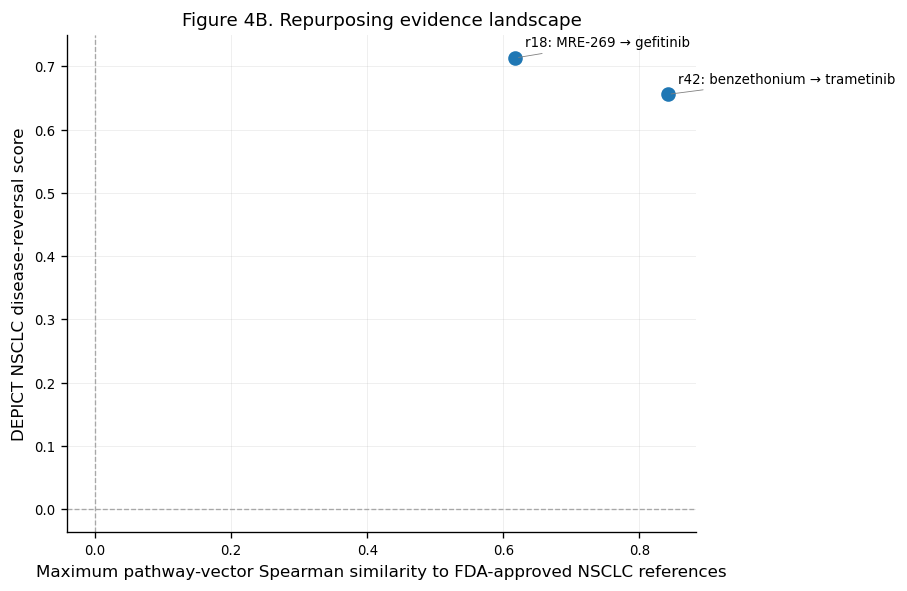

In [11]:
def repel_text_positions(df, y_col, min_gap_fraction=0.05):
    """Simple vertical label spreading for small scatter plots."""
    if df.empty:
        return []
    y = df[y_col].astype(float).to_numpy().copy()
    order = np.argsort(y)
    yrange = max(np.nanmax(y) - np.nanmin(y), 1e-6)
    min_gap = yrange * min_gap_fraction
    y_adj = y.copy()
    for i in range(1, len(order)):
        prev = order[i - 1]
        curr = order[i]
        if y_adj[curr] - y_adj[prev] < min_gap:
            y_adj[curr] = y_adj[prev] + min_gap
    return y_adj


def plot_fig4b_landscape(nearest_df):
    df = nearest_df.copy()
    if df.empty:
        print("No candidates available for Figure 4B.")
        return
    fig, ax = plt.subplots(figsize=(7.6, 5.0))
    ax.scatter(df["pathway_spearman_rho"], df["candidate_reverse_score"], s=60, zorder=3)
    ax.axvline(0, lw=0.8, ls="--", color="0.65", zorder=1)
    ax.axhline(0, lw=0.8, ls="--", color="0.65", zorder=1)
    ax.set_xlabel("Maximum pathway-vector Spearman similarity to FDA-approved NSCLC references")
    ax.set_ylabel("DEPICT NSCLC disease-reversal score")
    ax.set_title("Figure 4B. Repurposing evidence landscape")

    x_span = max(df["pathway_spearman_rho"].max() - df["pathway_spearman_rho"].min(), 0.2)
    for _, row in df.iterrows():
        rank_label = f"r{int(row['candidate_rank'])}" if pd.notna(row.get('candidate_rank', np.nan)) else "rNA"
        label = f"{rank_label}: {row['candidate']} → {row['reference']}"
        ax.annotate(
            label,
            xy=(row["pathway_spearman_rho"], row["candidate_reverse_score"]),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom",
            arrowprops=dict(arrowstyle="-", lw=0.5, color="0.5", shrinkA=2, shrinkB=2),
        )
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="both", alpha=0.20, linewidth=0.6)
    fig.tight_layout()
    save_figure(fig, "fig4b_repurposing_evidence_landscape_nearest_fda_nsclc_reference")

plot_fig4b_landscape(fig4b_nearest)


### Debugging note for version 10

The prior Figure 4C block referenced an undefined object named `observed_rank`. This version uses the notebook's actual observed A549 ranking table, `orig_ranked_all`. The final three Illustrator-ready outputs are now generated at fixed dimensions: Figure 4A at 7.5 × 3.4 inches, Figure 4B at 7.5 × 3.35 inches, and Figure 4C at 7.5 × 5.8 inches. Each is saved as PDF, SVG, and PNG.


### Figure-layout updates in version 11

- Figure 4A now places candidate summaries above each histogram and reports the candidate value, percentile, and one inclusive empirical p-value. The leave-one-out p-value remains archived in the result table only.
- Figure 4B reserves separate vertical space for the explanatory subtitle, x-axis title, and multi-column legend.
- Figure 4C uses a dedicated external colorbar axis so the legend cannot overlap the heatmaps.
- Candidate ranks have been removed from all figure-facing labels.


### Final layout polish in version 12

- Figure 4A uses metric-specific annotations such as `max ref sim = ...` or `... reversed pathways`, followed by percentile and the inclusive empirical p-value.
- Figure 4A and Figure 4B are resized for the left column; Figure 4C is resized for the right column.
- Figure 4B separates the observed-nearest-reference note from the x-axis label and uses adaptive in-bar font sizing.
- Figure 4C uses simplified drug labels, bolds only the DEPICT candidates, and enlarges the tile values.


## 13. Figure 4C — focused candidate/reference pathway-reversal heatmaps

This block compares each repurposing candidate with a prespecified group of observed FDA-approved NSCLC reference drugs on the original NSCLC-focused pathway panel. MRE-269 is shown with crizotinib, methotrexate, gefitinib, everolimus, and vinorelbine. Benzethonium is shown with gemcitabine, trametinib, and vinorelbine. Each tile contains the signed pathway-reversal score; positive values indicate reversal of the NSCLC-associated pathway direction.


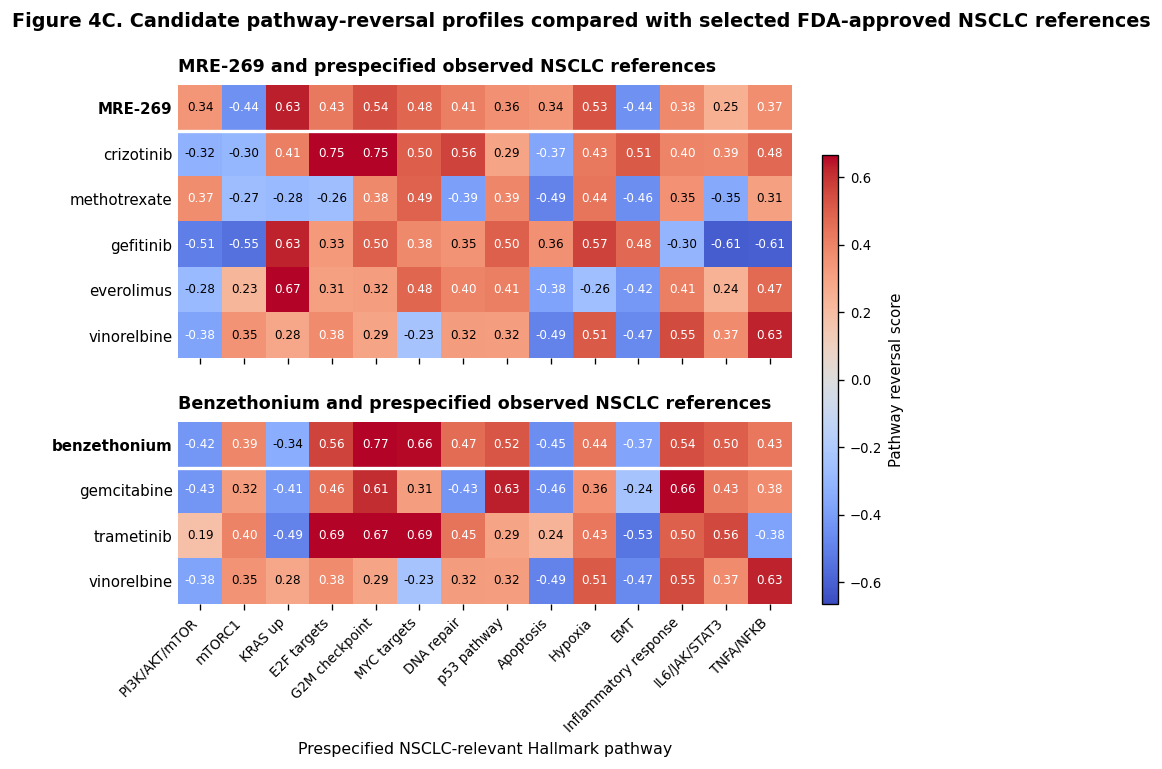


Figure 4C pathway-reversal matrix: MRE-269
------------------------------------------


,row_label,PI3K/AKT/mTOR,mTORC1,KRAS up,E2F targets,G2M checkpoint,MYC targets,DNA repair,p53 pathway,Apoptosis,Hypoxia,EMT,Inflammatory response,IL6/JAK/STAT3,TNFA/NFKB
0,MRE-269,0.342043,-0.444430,0.629489,0.429163,0.539360,0.482002,0.411076,0.362361,0.341330,0.527590,-0.443994,0.382502,0.254117,0.366039
1,crizotinib,-0.320728,-0.298664,0.412934,0.752686,0.749805,0.500379,0.563398,0.291251,-0.366025,0.428444,0.511211,0.397235,0.388981,0.475134
2,methotrexate,0.369830,-0.268104,-0.284041,-0.262604,0.380716,0.488531,-0.392852,0.388588,-0.491099,0.439733,-0.456273,0.353967,-0.353665,0.310901
3,gefitinib,-0.505390,-0.545567,0.627679,0.328758,0.498608,0.380175,0.352749,0.495246,0.358437,0.570519,0.476774,-0.303021,-0.610882,-0.606688
4,everolimus,-0.284416,0.226372,0.671333,0.308948,0.316288,0.478229,0.399066,0.414925,-0.384211,-0.257163,-0.418873,0.411180,0.241131,0.471235
5,vinorelbine,-0.376579,0.351755,0.280937,0.375850,0.294115,-0.234790,0.319081,0.316462,-0.492214,0.513519,-0.471505,0.547484,0.374980,0.626915


shape: (6, 15)

Figure 4C pathway-reversal matrix: benzethonium
-----------------------------------------------


,row_label,PI3K/AKT/mTOR,mTORC1,KRAS up,E2F targets,G2M checkpoint,MYC targets,DNA repair,p53 pathway,Apoptosis,Hypoxia,EMT,Inflammatory response,IL6/JAK/STAT3,TNFA/NFKB
0,benzethonium,-0.422924,0.394727,-0.339917,0.563690,0.769114,0.655044,0.465155,0.520135,-0.453427,0.437603,-0.371009,0.538129,0.499955,0.434308
1,gemcitabine,-0.430072,0.318179,-0.414902,0.460830,0.610629,0.311787,-0.426547,0.633733,-0.455858,0.358362,-0.237755,0.664853,0.427964,0.376883
2,trametinib,0.185393,0.400982,-0.492059,0.694575,0.665837,0.685772,0.446665,0.294228,0.237351,0.432768,-0.530199,0.498147,0.555094,-0.380803
3,vinorelbine,-0.376579,0.351755,0.280937,0.375850,0.294115,-0.234790,0.319081,0.316462,-0.492214,0.513519,-0.471505,0.547484,0.374980,0.626915


shape: (4, 15)


In [12]:
# Prespecified candidate/reference groups for the final Figure 4C panel.
FIG4C_REFERENCE_GROUPS = {
    "MRE-269": [
        "crizotinib",
        "methotrexate",
        "gefitinib",
        "everolimus",
        "vinorelbine",
    ],
    "benzethonium": [
        "gemcitabine",
        "trametinib",
        "vinorelbine",
    ],
}


def _resolve_observed_reference_rows(reference_names, observed_ranking):
    """
    Resolve requested reference names against the observed A549 ranking table.

    Matching uses the same normalized drug-name key used throughout the notebook.
    Missing drugs are reported explicitly rather than silently dropped.
    """
    requested = pd.DataFrame({
        "requested_name": reference_names,
        "drug_key": [normalize_drug_name(x) for x in reference_names],
    })

    observed_lookup = observed_ranking.copy()
    observed_lookup["drug_key"] = observed_lookup["pert_iname"].map(normalize_drug_name)
    observed_lookup = (
        observed_lookup
        .sort_values("rank")
        .drop_duplicates("drug_key", keep="first")
    )

    resolved = requested.merge(
        observed_lookup,
        on="drug_key",
        how="left",
        suffixes=("_requested", ""),
    )

    missing = resolved.loc[resolved["pert_iname"].isna(), "requested_name"].tolist()
    if missing:
        print("WARNING: requested observed references not found in observed ranking:", missing)

    resolved = resolved.dropna(subset=["pert_iname"]).copy()
    resolved["source"] = "Observed LINCS"
    resolved["drug_group"] = "Prespecified FDA-approved NSCLC reference"
    return resolved


def _candidate_profile_row(candidate_name):
    key = normalize_drug_name(candidate_name)
    sub = profiles[
        profiles["source"].eq("DEPICT-predicted LINCS")
        & profiles["drug_key"].eq(key)
    ].copy()
    if sub.empty:
        raise ValueError(f"No predicted DGE profile found for candidate: {candidate_name}")
    return sub.iloc[[0]].copy()


def _build_focused_fig4c_profiles():
    candidate_frames = []
    reference_frames = []

    all_requested_refs = sorted({
        ref
        for refs in FIG4C_REFERENCE_GROUPS.values()
        for ref in refs
    })

    resolved_refs = _resolve_observed_reference_rows(all_requested_refs, orig_ranked_all)
    if not resolved_refs.empty:
        reference_frames.append(
            attach_dge_profiles(
                resolved_refs,
                df_diffexp_obs,
                "Observed LINCS",
                common_gene_cols,
            )
        )

    for candidate_name in FIG4C_REFERENCE_GROUPS:
        candidate_frames.append(_candidate_profile_row(candidate_name))

    focused_profiles = pd.concat(
        candidate_frames + reference_frames,
        ignore_index=True,
        sort=False,
    )

    focused_profiles.to_csv(
        TABLE_DIR / "fig4c_focused_candidate_reference_profiles_with_dge.csv",
        index=False,
    )
    return focused_profiles


def _focused_pathway_reversal_scores(focused_profiles):
    scores = compute_pathway_reversal(
        focused_profiles,
        gmt_matched,
        disease_pathway_es,
        common_gene_cols,
    )
    scores.to_csv(
        TABLE_DIR / "fig4c_focused_candidate_reference_pathway_reversal_scores_long.csv",
        index=False,
    )
    return scores


def _vector_from_scores(scores, source, drug_name, columns):
    key = normalize_drug_name(drug_name)
    sub = scores[
        scores["source"].eq(source)
        & scores["drug_key"].eq(key)
    ].copy()
    if sub.empty:
        return None
    return (
        sub.groupby("pathway_display")["pathway_reversal_score"]
        .mean()
        .reindex(columns)
    )


def _text_color_for_heatmap_value(value, limit):
    if not np.isfinite(value) or limit <= 0:
        return "black"
    return "white" if abs(value) >= 0.55 * limit else "black"


def _build_group_matrix(scores, candidate_name, reference_names, columns):
    rows = []
    labels = []
    row_types = []

    candidate_vec = _vector_from_scores(
        scores,
        "DEPICT-predicted LINCS",
        candidate_name,
        columns,
    )
    if candidate_vec is None:
        raise ValueError(f"No pathway vector found for candidate: {candidate_name}")

    rows.append(candidate_vec)
    labels.append(candidate_name)
    row_types.append("candidate")

    for reference_name in reference_names:
        vec = _vector_from_scores(
            scores,
            "Observed LINCS",
            reference_name,
            columns,
        )
        if vec is None:
            print(f"WARNING: no observed pathway vector available for {reference_name}; omitted.")
            continue
        rows.append(vec)
        labels.append(reference_name)
        row_types.append("reference")

    matrix = pd.DataFrame(rows, index=labels, columns=columns)
    metadata = pd.DataFrame({
        "row_label": labels,
        "row_type": row_types,
        "candidate_group": candidate_name,
    })
    return matrix, metadata


def plot_fig4c_focused_candidate_reference_heatmaps(scores, annotate_values=True):
    """
    Plot two vertically stacked heatmaps with a common pathway order and color scale.

    Top panel:
        MRE-269 with crizotinib, methotrexate, gefitinib, everolimus, and vinorelbine.

    Bottom panel:
        benzethonium with gemcitabine, trametinib, and vinorelbine.
    """
    columns = [
        pathway
        for pathway in PATHWAY_DISPLAY_ORDER
        if pathway in scores["pathway_display"].unique()
    ]

    matrices = {}
    metadata_frames = []
    for candidate_name, reference_names in FIG4C_REFERENCE_GROUPS.items():
        matrix, metadata = _build_group_matrix(
            scores,
            candidate_name,
            reference_names,
            columns,
        )
        matrices[candidate_name] = matrix
        metadata_frames.append(metadata)

    all_values = np.concatenate([
        matrix.to_numpy(dtype=float).ravel()
        for matrix in matrices.values()
    ])
    finite_values = all_values[np.isfinite(all_values)]
    color_limit = (
        max(float(np.nanpercentile(np.abs(finite_values), 95)), 0.25)
        if finite_values.size
        else 1.0
    )

    n_rows_total = sum(matrix.shape[0] for matrix in matrices.values())
    fig_width = 7.3
    fig_height = 6.45

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(fig_width, fig_height),
        sharex=True,
        gridspec_kw={
            "height_ratios": [
                matrices["MRE-269"].shape[0],
                matrices["benzethonium"].shape[0],
            ],
            "hspace": 0.28,
        },
    )

    image = None
    panel_labels = {
        "MRE-269": "MRE-269 and prespecified observed NSCLC references",
        "benzethonium": "Benzethonium and prespecified observed NSCLC references",
    }

    for ax, candidate_name in zip(axes, ["MRE-269", "benzethonium"]):
        matrix = matrices[candidate_name]
        values = matrix.to_numpy(dtype=float)

        image = ax.imshow(
            values,
            aspect="auto",
            cmap="coolwarm",
            vmin=-color_limit,
            vmax=color_limit,
        )

        ax.set_yticks(np.arange(matrix.shape[0]))
        ax.set_yticklabels(matrix.index, fontsize=9.0)

        # Bold only the DEPICT candidate row.
        for tick_index, tick_label in enumerate(ax.get_yticklabels()):
            tick_label.set_fontweight("bold" if tick_index == 0 else "normal")

        ax.set_title(
            panel_labels[candidate_name],
            loc="left",
            fontsize=10.5,
            fontweight="bold",
            pad=8,
        )

        # Separate the candidate from its observed references.
        ax.axhline(0.5, color="white", linewidth=2.0)

        if annotate_values:
            for i in range(matrix.shape[0]):
                for j in range(matrix.shape[1]):
                    value = values[i, j]
                    if not np.isfinite(value):
                        continue
                    ax.text(
                        j,
                        i,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                        fontsize=7.2,
                        color=_text_color_for_heatmap_value(value, color_limit),
                    )

        ax.tick_params(axis="y", length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

    axes[-1].set_xticks(np.arange(len(columns)))
    axes[-1].set_xticklabels(
        columns,
        rotation=45,
        ha="right",
        fontsize=8,
    )
    axes[-1].set_xlabel("Prespecified NSCLC-relevant Hallmark pathway", fontsize=9.5)

    fig.suptitle(
        "Figure 4C. Candidate pathway-reversal profiles compared with selected FDA-approved NSCLC references",
        x=0.01,
        ha="left",
        fontsize=11.5,
        fontweight="bold",
        y=0.995,
    )

    # Dedicated colorbar axis outside the heatmaps prevents overlap.
    cax = fig.add_axes([0.935, 0.23, 0.018, 0.58])
    cbar = fig.colorbar(image, cax=cax)
    cbar.set_label("Pathway reversal score", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    fig.subplots_adjust(left=0.20, right=0.90, bottom=0.23, top=0.90)
    save_figure(fig, "fig4c_focused_candidate_selected_reference_pathway_reversal_heatmaps")

    combined_matrix = pd.concat(
        [
            matrix.assign(candidate_group=candidate_name)
            for candidate_name, matrix in matrices.items()
        ],
        axis=0,
    )
    combined_metadata = pd.concat(metadata_frames, ignore_index=True)

    combined_matrix.to_csv(
        TABLE_DIR / "fig4c_focused_candidate_selected_reference_heatmap_matrix.csv"
    )
    combined_metadata.to_csv(
        TABLE_DIR / "fig4c_focused_candidate_selected_reference_heatmap_row_metadata.csv",
        index=False,
    )

    return matrices, combined_metadata


fig4c_focused_profiles = _build_focused_fig4c_profiles()
fig4c_focused_pathway_scores = _focused_pathway_reversal_scores(fig4c_focused_profiles)
fig4c_group_matrices, fig4c_group_row_metadata = (
    plot_fig4c_focused_candidate_reference_heatmaps(
        fig4c_focused_pathway_scores,
        annotate_values=True,
    )
)

for candidate_name, matrix in fig4c_group_matrices.items():
    show_df(
        matrix.reset_index().rename(columns={"index": "row_label"}),
        f"Figure 4C pathway-reversal matrix: {candidate_name}",
        100,
    )


## 14. Figure 4C-right — optional target/module proximity dot plot

This block tries to use the `target` column from Drug Repurposing Hub to map known drug targets to the selected Hallmark pathway modules. Dot size reflects the number of known targets found in each pathway gene set; dot color reflects the DEPICT pathway-reversal score. If target coverage is sparse, this panel should be treated as optional or supplementary.


In [13]:
def build_target_module_table(candidates, drug_meta, pathway_scores, gmt_matched):
    if "target" not in drug_meta.columns:
        print("No `target` column found in drug_meta. Skipping target/module proximity table.")
        return pd.DataFrame()

    cand_meta = candidates[["pert_iname", "drug_key", "rank", "reverse_score"]].merge(
        drug_meta[["drug_key", "target"]].drop_duplicates("drug_key"),
        on="drug_key",
        how="left",
    )
    cand_meta["target_genes"] = cand_meta["target"].apply(split_targets)

    score_wide = pathway_scores[pathway_scores["source"] == "DEPICT-predicted LINCS"].pivot_table(
        index="drug_key",
        columns="pathway_raw",
        values="pathway_reversal_score",
        aggfunc="mean",
    )

    records = []
    for _, row in cand_meta.iterrows():
        targets = set(row["target_genes"])
        for pathway_raw, genes in gmt_matched.items():
            overlap = sorted(targets.intersection(set(genes)))
            records.append({
                "pert_iname": row["pert_iname"],
                "drug_key": row["drug_key"],
                "rank": row["rank"],
                "target": row.get("target", np.nan),
                "target_genes_parsed": ";".join(sorted(targets)),
                "pathway_raw": pathway_raw,
                "pathway_display": PATHWAY_RENAME.get(pathway_raw, pathway_raw),
                "n_target_genes_in_module": len(overlap),
                "target_genes_in_module": ";".join(overlap),
                "has_direct_module_target": len(overlap) > 0,
                "pathway_reversal_score": score_wide.loc[row["drug_key"], pathway_raw] if row["drug_key"] in score_wide.index and pathway_raw in score_wide.columns else np.nan,
            })
    return pd.DataFrame(records)


def plot_fig4c_target_dotplot(target_module_df):
    df = target_module_df.copy()
    if df.empty:
        print("Target/module table is empty; skipping dot plot.")
        return
    if df["n_target_genes_in_module"].sum() == 0:
        print("No direct target-module overlaps found. Dot plot may not be informative; saving table only.")
        return

    # Keep all candidate/pathway combinations, but only direct overlaps get visible sizes.
    row_order = (
        df[["rank", "pert_iname"]].drop_duplicates().sort_values("rank")["pert_iname"].tolist()
    )
    col_order = [p for p in PATHWAY_DISPLAY_ORDER if p in set(df["pathway_display"])]
    x_map = {p: i for i, p in enumerate(col_order)}
    y_map = {d: i for i, d in enumerate(row_order)}
    df["x"] = df["pathway_display"].map(x_map)
    df["y"] = df["pert_iname"].map(y_map)
    df["dot_size"] = 18 + 65 * df["n_target_genes_in_module"].clip(0, 4)
    lim = _symmetric_limit(df["pathway_reversal_score"], q=95, min_lim=0.25)

    fig_width = max(8.0, 0.42 * len(col_order) + 2.0)
    fig_height = max(3.5, 0.45 * len(row_order) + 1.8)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sc = ax.scatter(
        df["x"],
        df["y"],
        s=df["dot_size"],
        c=df["pathway_reversal_score"],
        cmap="coolwarm",
        vmin=-lim,
        vmax=lim,
        edgecolor="0.35",
        linewidth=0.3,
    )
    ax.set_xticks(np.arange(len(col_order)))
    ax.set_xticklabels(col_order, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(row_order)))
    ax.set_yticklabels(row_order)
    ax.set_title("Figure 4C-right. Known target overlap with NSCLC pathway modules")
    ax.set_xlabel("NSCLC-relevant Hallmark pathway")
    ax.set_ylabel("Candidate")
    cbar = fig.colorbar(sc, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Pathway reversal score")

    legend_handles = [
        Line2D([0], [0], marker="o", color="w", label="1 target", markerfacecolor="0.7", markeredgecolor="0.35", markersize=np.sqrt(18 + 65 * 1)),
        Line2D([0], [0], marker="o", color="w", label="2 targets", markerfacecolor="0.7", markeredgecolor="0.35", markersize=np.sqrt(18 + 65 * 2)),
        Line2D([0], [0], marker="o", color="w", label="≥3 targets", markerfacecolor="0.7", markeredgecolor="0.35", markersize=np.sqrt(18 + 65 * 3)),
    ]
    ax.legend(handles=legend_handles, title="Known targets in module", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.tight_layout()
    save_figure(fig, "fig4c_candidate_target_module_proximity_dotplot")

fig4c_target_module_df = build_target_module_table(primary_candidates, drug_meta, pathway_scores, gmt_matched)
fig4c_target_module_df.to_csv(TABLE_DIR / "fig4c_candidate_target_module_proximity_long.csv", index=False)
show_df(fig4c_target_module_df, "Figure 4C target/module proximity table", 100)
plot_fig4c_target_dotplot(fig4c_target_module_df)



Figure 4C target/module proximity table
---------------------------------------


,pert_iname,drug_key,rank,target,target_genes_parsed,pathway_raw,pathway_display,n_target_genes_in_module,target_genes_in_module,has_direct_module_target,pathway_reversal_score
0,MRE-269,mre269,18,NaN,,HALLMARK_PI3K_AKT_MTOR_SIGNALING,PI3K/AKT/mTOR,0,,False,0.342043
1,MRE-269,mre269,18,NaN,,HALLMARK_MTORC1_SIGNALING,mTORC1,0,,False,-0.444430
2,MRE-269,mre269,18,NaN,,HALLMARK_KRAS_SIGNALING_UP,KRAS up,0,,False,0.629489
3,MRE-269,mre269,18,NaN,,HALLMARK_E2F_TARGETS,E2F targets,0,,False,0.429163
4,MRE-269,mre269,18,NaN,,HALLMARK_G2M_CHECKPOINT,G2M checkpoint,0,,False,0.539360
5,MRE-269,mre269,18,NaN,,HALLMARK_MYC_TARGETS_V1,MYC targets,0,,False,0.482002
6,MRE-269,mre269,18,NaN,,HALLMARK_DNA_REPAIR,DNA repair,0,,False,0.411076
7,MRE-269,mre269,18,NaN,,HALLMARK_P53_PATHWAY,p53 pathway,0,,False,0.362361
8,MRE-269,mre269,18,NaN,,HALLMARK_APOPTOSIS,Apoptosis,0,,False,0.341330
9,MRE-269,mre269,18,NaN,,HALLMARK_HYPOXIA,Hypoxia,0,,False,0.527590


shape: (28, 11)
No direct target-module overlaps found. Dot plot may not be informative; saving table only.


## 15. Figure 4D data — repurposing-readiness matrix

This block integrates the candidate-level evidence layers: DEPICT rank, disease-reversal score, pathway-reversal breadth, nearest FDA-approved NSCLC reference, complementarity, target/module support, FDA indication context, oncology use annotations if available, and a rule-based candidate role.


In [14]:
def make_readiness_matrix(candidates, pathway_scores, nearest_df, target_module_df):
    cand = candidates.copy()
    cand = cand.sort_values("rank").reset_index(drop=True)

    # Pathway breadth.
    cand_path = pathway_scores[pathway_scores["source"] == "DEPICT-predicted LINCS"].copy()
    breadth = (
        cand_path.assign(reversed_pathway=lambda x: x["pathway_reversal_score"] > PATHWAY_BREADTH_THRESHOLD)
        .groupby(["drug_key", "pert_iname"], as_index=False)
        .agg(
            pathway_reversal_breadth=("reversed_pathway", "sum"),
            mean_pathway_reversal=("pathway_reversal_score", "mean"),
            max_pathway_reversal=("pathway_reversal_score", "max"),
        )
    )

    # Nearest reference and complementarity.
    nearest = nearest_df.copy()
    comp_records = []
    if not nearest.empty:
        score_wide = pathway_scores.pivot_table(
            index=["source", "pert_iname", "drug_key"],
            columns="pathway_display",
            values="pathway_reversal_score",
            aggfunc="mean",
        )
        for _, row in nearest.iterrows():
            cand_key = row["candidate_key"]
            ref_key = row["reference_key"]
            cidx = next((idx for idx in score_wide.index if idx[0] == "DEPICT-predicted LINCS" and idx[2] == cand_key), None)
            ridx = next((idx for idx in score_wide.index if idx[0] == "Observed LINCS" and idx[2] == ref_key), None)
            if cidx is None or ridx is None:
                comp = np.nan
            else:
                cvec = score_wide.loc[cidx]
                rvec = score_wide.loc[ridx]
                comp = int(((cvec > PATHWAY_BREADTH_THRESHOLD) & ~(rvec > PATHWAY_BREADTH_THRESHOLD)).sum())
            comp_records.append({"candidate_key": cand_key, "complementarity_score": comp})
    comp_df = pd.DataFrame(comp_records)

    # Target/module support.
    if target_module_df is not None and not target_module_df.empty:
        target_summary = (
            target_module_df.groupby(["drug_key", "pert_iname"], as_index=False)
            .agg(
                n_modules_with_direct_target=("has_direct_module_target", "sum"),
                total_target_module_hits=("n_target_genes_in_module", "sum"),
                target_genes_parsed=("target_genes_parsed", lambda x: ";".join(sorted(set(";".join(x.dropna().astype(str)).split(";")) - {""}))),
            )
        )
    else:
        target_summary = pd.DataFrame(columns=["drug_key", "pert_iname", "n_modules_with_direct_target", "total_target_module_hits", "target_genes_parsed"])

    out = cand.merge(breadth, on=["drug_key", "pert_iname"], how="left")
    out = out.merge(
        nearest[["candidate_key", "reference", "pathway_spearman_rho"]].rename(columns={
            "candidate_key": "drug_key",
            "reference": "nearest_fda_nsclc_reference",
            "pathway_spearman_rho": "max_pathway_similarity",
        }),
        on="drug_key",
        how="left",
    )
    if not comp_df.empty:
        out = out.merge(comp_df.rename(columns={"candidate_key": "drug_key"}), on="drug_key", how="left")
    else:
        out["complementarity_score"] = np.nan
    out = out.merge(target_summary.drop(columns=["pert_iname"], errors="ignore"), on="drug_key", how="left")

    # Current approved-use context from Drug Repurposing Hub if available.
    if "disease_area" in out.columns:
        out["fda_indication_category"] = out["disease_area"]
    elif "indication" in out.columns:
        out["fda_indication_category"] = out["indication"]
    else:
        out["fda_indication_category"] = "FDA-approved; category not annotated"

    # Existing oncology use is an annotation only; exact source depends on Drug Repurposing Hub fields.
    text_cols = [c for c in ["disease_area", "indication", "moa", "mechanism_of_action"] if c in out.columns]
    if text_cols:
        concat_text = out[text_cols].fillna("").agg(" ".join, axis=1).str.lower()
        out["existing_oncology_use_annotation"] = np.where(concat_text.str.contains("cancer|oncology|tumor|neoplasm|malignan"), "possible oncology use", "not annotated as oncology")
    else:
        out["existing_oncology_use_annotation"] = "not annotated"

    # Rule-based role assignment.
    def assign_role(r):
        high_sim = pd.notna(r.get("max_pathway_similarity")) and r.get("max_pathway_similarity") >= HIGH_SIMILARITY_RHO
        high_comp = pd.notna(r.get("complementarity_score")) and r.get("complementarity_score") >= HIGH_COMPLEMENTARITY_N
        has_target = pd.notna(r.get("n_modules_with_direct_target")) and r.get("n_modules_with_direct_target") > 0
        if high_sim:
            return "substitute-like"
        if high_comp:
            return "combination-like"
        if has_target and not high_sim:
            return "mechanistically distinct"
        return "exploratory"

    out["candidate_role"] = out.apply(assign_role, axis=1)
    keep_cols = [
        "pert_iname", "rank", "reverse_score", "pathway_reversal_breadth", "mean_pathway_reversal", "max_pathway_reversal",
        "nearest_fda_nsclc_reference", "max_pathway_similarity", "complementarity_score",
        "n_modules_with_direct_target", "total_target_module_hits", "target_genes_parsed",
        "clinical_phase", "fda_indication_category", "existing_oncology_use_annotation", "candidate_role",
        "observed_screening_present", "fda_approved_any_disease", "nsclc_approved_fda",
    ]
    keep_cols = [c for c in keep_cols if c in out.columns]
    return out[keep_cols].sort_values("rank").reset_index(drop=True)

fig4d_readiness = make_readiness_matrix(primary_candidates, pathway_scores, fig4b_nearest, fig4c_target_module_df)
fig4d_readiness.to_csv(TABLE_DIR / "fig4d_repurposing_readiness_matrix.csv", index=False)
show_df(fig4d_readiness, "Figure 4D repurposing-readiness matrix", 100)



Figure 4D repurposing-readiness matrix
--------------------------------------


,pert_iname,rank,reverse_score,pathway_reversal_breadth,mean_pathway_reversal,max_pathway_reversal,nearest_fda_nsclc_reference,max_pathway_similarity,complementarity_score,n_modules_with_direct_target,total_target_module_hits,target_genes_parsed,clinical_phase,fda_indication_category,existing_oncology_use_annotation,candidate_role,observed_screening_present,fda_approved_any_disease,nsclc_approved_fda
0,MRE-269,18,0.713321,12,0.298475,0.629489,gefitinib,0.617582,4,0,0,,NaN,NaN,not annotated as oncology,substitute-like,False,NaN,False
1,benzethonium,42,0.655718,10,0.263613,0.769114,trametinib,0.841758,1,0,0,SCN10A,Launched,infectious disease,not annotated as oncology,substitute-like,False,True,False


shape: (2, 19)


## 16. Plot Figure 4D — compact readiness matrix/table

This block renders a compact table-like panel for the selected candidates. For a large candidate set, the top `N_MAIN_FIG4D` candidates are shown in the main figure while the full table remains saved.


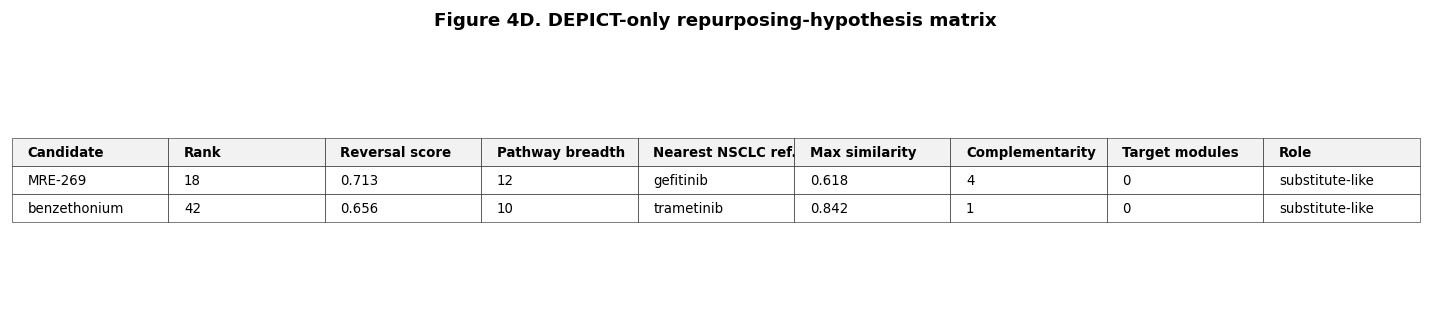

In [15]:
N_MAIN_FIG4D = 10

def plot_fig4d_readiness_table(readiness_df, n_main=N_MAIN_FIG4D):
    df = readiness_df.copy().head(n_main)
    if df.empty:
        print("No candidates available for Figure 4D.")
        return
    display_cols = [
        "pert_iname", "rank", "reverse_score", "pathway_reversal_breadth",
        "nearest_fda_nsclc_reference", "max_pathway_similarity", "complementarity_score",
        "n_modules_with_direct_target", "candidate_role",
    ]
    display_cols = [c for c in display_cols if c in df.columns]
    tbl = df[display_cols].copy()
    rename = {
        "pert_iname": "Candidate",
        "rank": "Rank",
        "reverse_score": "Reversal score",
        "pathway_reversal_breadth": "Pathway breadth",
        "nearest_fda_nsclc_reference": "Nearest NSCLC ref.",
        "max_pathway_similarity": "Max similarity",
        "complementarity_score": "Complementarity",
        "n_modules_with_direct_target": "Target modules",
        "candidate_role": "Role",
    }
    tbl = tbl.rename(columns=rename)

    for c in ["Reversal score", "Max similarity"]:
        if c in tbl.columns:
            tbl[c] = tbl[c].map(lambda x: "" if pd.isna(x) else f"{float(x):.3f}")
    for c in ["Rank", "Pathway breadth", "Complementarity", "Target modules"]:
        if c in tbl.columns:
            tbl[c] = tbl[c].map(lambda x: "" if pd.isna(x) else f"{int(x)}")

    fig_height = max(2.8, 0.42 * len(tbl) + 1.2)
    fig_width = 12.0
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    table = ax.table(
        cellText=tbl.values,
        colLabels=tbl.columns,
        loc="center",
        cellLoc="left",
        colLoc="left",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.35)
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.3)
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#F2F2F2")
    ax.set_title("Figure 4D. DEPICT-only repurposing-hypothesis matrix", pad=12, fontweight="bold")
    fig.tight_layout()
    save_figure(fig, "fig4d_repurposing_readiness_matrix_table")

plot_fig4d_readiness_table(fig4d_readiness)


## 17. Optional supplement — broader observed top-50 NSCLC-relevant MoA reference sensitivity

This optional block prepares a placeholder for the broader sensitivity reference set discussed in the plan. Fill in `NSCLC_RELEVANT_MOA_REGEX` based on your observed-ranking MoA annotation columns if you want to compare Figure 4B against observed top-50 drugs with relevant MoAs, not only FDA-approved NSCLC references.


In [16]:
NSCLC_RELEVANT_MOA_REGEX = r"PI3K|AKT|MTOR|mTOR|EGFR|ERBB|ALK|ROS|MET|RTK|TKI|MEK|MAPK|BRAF|KRAS|CDK|cell cycle|CHK|checkpoint|DNA|topoisomerase|apoptosis|p53"

possible_moa_cols = [c for c in ["moa", "mechanism_of_action", "class_for_figure3", "target", "known_moa"] if c in orig_ranked_all.columns]
if possible_moa_cols:
    top_obs = orig_ranked_all[orig_ranked_all["rank"] <= PRIMARY_TOP_N].copy()
    text = top_obs[possible_moa_cols].fillna("").agg(" ".join, axis=1)
    broader_refs = top_obs[text.str.contains(NSCLC_RELEVANT_MOA_REGEX, case=False, regex=True, na=False)].copy()
    broader_refs.to_csv(TABLE_DIR / "supp_fig4b_observed_top50_nsclc_relevant_moa_reference_candidates.csv", index=False)
    show_df(broader_refs[["pert_iname", "rank", "reverse_score"] + possible_moa_cols], "Supplemental broader observed top-50 MoA reference candidates", 100)
else:
    print("No MoA-like columns found in observed ranking. This sensitivity block is skipped unless you merge MoA annotations into `orig_ranked_all`.")


No MoA-like columns found in observed ranking. This sensitivity block is skipped unless you merge MoA annotations into `orig_ranked_all`.


## 18. Output summary

This block prints the main figure and table paths to inspect after the notebook has run.


In [17]:
print("Figures saved in:", FIG_DIR)
print("Tables saved in:", TABLE_DIR)

main_figures = [
    "fig4a_candidate_selection_funnel.pdf",
    "fig4b_repurposing_evidence_landscape_nearest_fda_nsclc_reference.pdf",
    "fig4c_candidate_pathway_reversal_heatmap.pdf",
    "fig4c_candidate_target_module_proximity_dotplot.pdf",
    "fig4d_repurposing_readiness_matrix_table.pdf",
]
print("\nMain figure files:")
for fn in main_figures:
    p = FIG_DIR / fn
    print(" -", p, "OK" if p.exists() else "missing/skipped")

main_tables = [
    "fig4a_candidate_selection_funnel_counts.csv",
    "fig4_top50_depict_only_candidate_pool_before_manual_selection.csv",
    "fig4_manual_candidate_match_audit_mre269_benzethonium.csv",
    "fig4_primary_mre269_benzethonium_candidates.csv",
    "fig4_selected_fda_nsclc_reference_drugs_observed.csv",
    "fig4_drug_level_pathway_reversal_scores_long.csv",
    "fig4b_nearest_fda_nsclc_reference_by_candidate.csv",
    "fig4c_candidate_nearest_reference_pathway_reversal_heatmap_matrix.csv",
    "fig4c_candidate_target_module_proximity_long.csv",
    "fig4d_repurposing_readiness_matrix.csv",
]
print("\nMain table files:")
for fn in main_tables:
    p = TABLE_DIR / fn
    print(" -", p, "OK" if p.exists() else "missing/skipped")


Figures saved in: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/figures
Tables saved in: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/tables

Main figure files:
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/figures/fig4a_candidate_selection_funnel.pdf OK
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/figures/fig4b_repurposing_evidence_landscape_nearest_fda_nsclc_reference.pdf OK
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_

## 19. Build all-Hallmark pathway-reversal matrix for matched-null and bootstrap analyses

This block expands the pathway-reversal calculation from the smaller display panel to **all Hallmark pathways**. The same signed preranked GSEA logic is used as before: positive pathway-reversal values mean the drug pushes the pathway opposite to the NSCLC tumor-vs-normal pathway direction. The resulting all-Hallmark matrix is used for the matched-null comparison and bootstrap nearest-reference frequency analysis.


In [18]:

# -----------------------------------------------------------------------------
# Figure 4B / Bootstrap settings.
# -----------------------------------------------------------------------------
MATCHED_NULL_TOP_N = 500
MATCHED_NULL_MIN_N = 30
BOOTSTRAP_B = 5000
BOOTSTRAP_RANDOM_SEED = 20260711
MATCHED_NULL_BREADTH_THRESHOLD = 0.0

# Candidate drugs to mark and bootstrap. Use the same selected candidate list as the focused Figure 4 analysis.
BOOTSTRAP_CANDIDATE_NAMES = SELECTED_CANDIDATE_NAMES
BOOTSTRAP_CANDIDATE_KEYS = {normalize_drug_name(x) for x in BOOTSTRAP_CANDIDATE_NAMES}

# Output labels.
MATCHED_NULL_LABELS = {
    "N1": "N1 strict: top 500 + DEPICT-only + Launched + non-NSCLC",
    "N2b": "N2b: all screened + DEPICT-only + Launched + non-NSCLC",
    "N2": "N2 relaxed: top 500 + Launched + non-NSCLC",
    "N3": "N3 broad: all screened + Launched + non-NSCLC",
}


def hallmark_display_name(pathway_raw):
    """Readable display name for all Hallmark pathways."""
    if pathway_raw in PATHWAY_RENAME:
        return PATHWAY_RENAME[pathway_raw]
    x = str(pathway_raw).replace("HALLMARK_", "")
    x = x.replace("_", " ").title()
    x = x.replace("Pi3K", "PI3K").replace("Akt", "AKT").replace("Mtor", "mTOR")
    x = x.replace("Tnfa", "TNFA").replace("Nfkb", "NFKB")
    x = x.replace("Il6", "IL6").replace("Jak", "JAK").replace("Stat3", "STAT3")
    x = x.replace("Kras", "KRAS").replace("P53", "p53").replace("G2M", "G2M")
    return x


def compute_pathway_reversal_generic(profile_df, gmt_matched, disease_pathway_es, gene_cols, display_map=None):
    """Compute signed pathway-reversal scores for an arbitrary pathway dictionary."""
    display_map = display_map or {}
    records = []
    for _, row in profile_df.iterrows():
        # Keep only numeric gene columns available in this row.
        dge = pd.Series({str(g).upper(): row.get(g, np.nan) for g in gene_cols}, dtype="float64").dropna()
        for pathway, genes in gmt_matched.items():
            drug_es = signed_preranked_es(dge, genes)
            disease_es = disease_pathway_es.get(pathway, np.nan)
            reversal = -np.sign(disease_es) * drug_es if pd.notna(drug_es) and pd.notna(disease_es) else np.nan
            records.append({
                "source": row.get("source", np.nan),
                "pert_iname": row.get("pert_iname", np.nan),
                "drug_key": row.get("drug_key", np.nan),
                "rank": row.get("rank", np.nan),
                "reverse_score": row.get("reverse_score", np.nan),
                "drug_group": row.get("drug_group", np.nan),
                "null_universe": row.get("null_universe", np.nan),
                "is_focus_candidate": bool(row.get("is_focus_candidate", False)),
                "pathway_raw": pathway,
                "pathway_display": display_map.get(pathway, hallmark_display_name(pathway)),
                "n_genes_in_pathway": len(genes),
                "drug_signed_es": drug_es,
                "disease_signed_es_tumor_vs_normal": disease_es,
                "pathway_reversal_score": reversal,
            })
    return pd.DataFrame(records)


# Match all Hallmark gene sets using the same strict overlap QC as the
# new-compound analysis, so both analyses use the same 34 Hallmark pathways.
gene_universe_upper = {str(g).upper() for g in common_gene_cols}
disease_gene_universe = set(disease_score.index.astype(str).str.upper())
ALL_HALLMARK_MIN_OVERLAP_FRACTION = 0.10

gmt_all_hallmark_matched = {}
for name, genes in gmt_all.items():
    original = {str(g).upper() for g in genes}
    dge_overlap = sorted(original & gene_universe_upper)
    disease_overlap = sorted(original & disease_gene_universe)
    n_original = len(original)

    retain_overlap = (
        len(dge_overlap) >= MIN_LANDMARK_OVERLAP
        and len(disease_overlap) >= MIN_LANDMARK_OVERLAP
        and (len(dge_overlap) / n_original if n_original else 0) >= ALL_HALLMARK_MIN_OVERLAP_FRACTION
        and (len(disease_overlap) / n_original if n_original else 0) >= ALL_HALLMARK_MIN_OVERLAP_FRACTION
    )
    if retain_overlap:
        gmt_all_hallmark_matched[name] = dge_overlap
ALL_HALLMARK_DISPLAY_MAP = {p: hallmark_display_name(p) for p in gmt_all_hallmark_matched}
ALL_HALLMARK_DISPLAY_ORDER = [ALL_HALLMARK_DISPLAY_MAP[p] for p in gmt_all_hallmark_matched]

all_hallmark_match_summary = pd.DataFrame({
    "pathway_raw": list(gmt_all_hallmark_matched.keys()),
    "pathway_display": [ALL_HALLMARK_DISPLAY_MAP[p] for p in gmt_all_hallmark_matched.keys()],
    "n_genes_matched_to_dge": [len(v) for v in gmt_all_hallmark_matched.values()],
}).sort_values("pathway_raw")
all_hallmark_match_summary.to_csv(TABLE_DIR / "fig4_all_hallmark_pathway_match_summary.csv", index=False)

print("Number of Hallmark pathways matched to DGE gene universe:", len(gmt_all_hallmark_matched))
show_df(all_hallmark_match_summary, "All-Hallmark pathway match summary", 60)

# NSCLC tumor-vs-normal pathway direction for all Hallmark pathways.
disease_pathway_es_all_hallmark = {
    pathway: signed_preranked_es(disease_score, genes)
    for pathway, genes in gmt_all_hallmark_matched.items()
}

disease_pathway_all_hallmark_df = pd.DataFrame({
    "pathway_raw": list(disease_pathway_es_all_hallmark.keys()),
    "pathway_display": [ALL_HALLMARK_DISPLAY_MAP[p] for p in disease_pathway_es_all_hallmark.keys()],
    "disease_signed_es_tumor_vs_normal": list(disease_pathway_es_all_hallmark.values()),
})
disease_pathway_all_hallmark_df["disease_direction_sign"] = np.sign(
    disease_pathway_all_hallmark_df["disease_signed_es_tumor_vs_normal"]
)
disease_pathway_all_hallmark_df.to_csv(TABLE_DIR / "fig4_all_hallmark_nsclc_disease_pathway_direction.csv", index=False)
show_df(disease_pathway_all_hallmark_df, "All-Hallmark NSCLC disease pathway direction", 60)


Number of Hallmark pathways matched to DGE gene universe: 34

All-Hallmark pathway match summary
----------------------------------


,pathway_raw,pathway_display,n_genes_matched_to_dge
0,HALLMARK_ADIPOGENESIS,Adipogenesis,25
1,HALLMARK_ALLOGRAFT_REJECTION,Allograft Rejection,24
2,HALLMARK_ANDROGEN_RESPONSE,Androgen Response,19
3,HALLMARK_APICAL_JUNCTION,Apical Junction,29
4,HALLMARK_APOPTOSIS,Apoptosis,40
5,HALLMARK_CHOLESTEROL_HOMEOSTASIS,Cholesterol Homeostasis,17
6,HALLMARK_COMPLEMENT,Complement,30
7,HALLMARK_DNA_REPAIR,DNA repair,23
8,HALLMARK_E2F_TARGETS,E2F targets,53
9,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,EMT,25


shape: (34, 3)

All-Hallmark NSCLC disease pathway direction
--------------------------------------------


,pathway_raw,pathway_display,disease_signed_es_tumor_vs_normal,disease_direction_sign
0,HALLMARK_ADIPOGENESIS,Adipogenesis,-0.265511,-1.0
1,HALLMARK_ALLOGRAFT_REJECTION,Allograft Rejection,-0.525804,-1.0
2,HALLMARK_ANDROGEN_RESPONSE,Androgen Response,-0.171668,-1.0
3,HALLMARK_APICAL_JUNCTION,Apical Junction,-0.377439,-1.0
4,HALLMARK_APOPTOSIS,Apoptosis,0.264561,1.0
5,HALLMARK_CHOLESTEROL_HOMEOSTASIS,Cholesterol Homeostasis,0.416051,1.0
6,HALLMARK_COMPLEMENT,Complement,-0.372203,-1.0
7,HALLMARK_DNA_REPAIR,DNA repair,0.569411,1.0
8,HALLMARK_E2F_TARGETS,E2F targets,0.775382,1.0
9,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,EMT,0.536270,1.0


shape: (34, 4)


## 20. Construct matched-null universes and attach predicted/observed DGE profiles

This block constructs the matched FDA null universes. The strict primary null is **N1: DEPICT top 500 ∩ absent from observed A549 ∩ clinical_phase == Launched ∩ not FDA-approved for NSCLC**. If N1 contains fewer than 30 drugs, the notebook now uses **N2b: all screened FDA-approved/Launched drugs that remain DEPICT-only in A549 and are not NSCLC-approved**. This retains the key DEPICT-only and FDA-matched properties while removing the top-500 restriction that made the earlier fallback less relevant. MRE-269 and benzethonium remain included in the plotted empirical distribution.


In [19]:
# -----------------------------------------------------------------------------
# Build candidate-like predicted-drug universe for matched null.
# -----------------------------------------------------------------------------
observed_a549_keys = set(orig_ranked_all["drug_key"].dropna())
fda_nsclc_keys = set(fda_nsclc_expanded["drug_key"].dropna())

# Start from all predicted screened drugs and attach Drug Repurposing Hub metadata.
pred_universe = pred_ranked_all.copy()
pred_universe = pred_universe.merge(
    drug_meta.drop_duplicates("drug_key"),
    on="drug_key",
    how="left",
    suffixes=("", "_drugmeta"),
)

pred_universe["observed_a549_screen_present"] = pred_universe["drug_key"].isin(observed_a549_keys)
pred_universe["is_fda_nsclc_approved"] = pred_universe["drug_key"].isin(fda_nsclc_keys)
pred_universe["clinical_phase_clean"] = pred_universe.get(
    "clinical_phase_clean", pred_universe.get("clinical_phase", "")
).astype(str).str.strip()
pred_universe["is_launched_drughub"] = pred_universe["clinical_phase_clean"].str.lower().eq("launched")
pred_universe["is_focus_candidate"] = pred_universe["drug_key"].isin(BOOTSTRAP_CANDIDATE_KEYS)

# N1: strict rank-matched, DEPICT-only FDA null.
N1_base = pred_universe[
    (pred_universe["rank"] <= MATCHED_NULL_TOP_N)
    & (~pred_universe["observed_a549_screen_present"])
    & (pred_universe["is_launched_drughub"])
    & (~pred_universe["is_fda_nsclc_approved"])
].copy()
N1_base["null_universe"] = "N1"

# N2b: all-screened, DEPICT-only FDA null requested for the primary fallback.
# It preserves FDA approval, non-NSCLC status, and absence from observed A549,
# but removes the top-500 restriction to obtain a more stable empirical distribution.
N2b_base = pred_universe[
    (~pred_universe["observed_a549_screen_present"])
    & (pred_universe["is_launched_drughub"])
    & (~pred_universe["is_fda_nsclc_approved"])
].copy()
N2b_base["null_universe"] = "N2b"

# Retain the previous relaxed universes for transparent sensitivity summaries only.
N2_base = pred_universe[
    (pred_universe["rank"] <= MATCHED_NULL_TOP_N)
    & (pred_universe["is_launched_drughub"])
    & (~pred_universe["is_fda_nsclc_approved"])
].copy()
N2_base["null_universe"] = "N2"

N3_base = pred_universe[
    (pred_universe["is_launched_drughub"])
    & (~pred_universe["is_fda_nsclc_approved"])
].copy()
N3_base["null_universe"] = "N3"

# Prespecified focused candidates are included in the plotted empirical distribution.
# This remains transparent even when Drug Repurposing Hub does not label a candidate as Launched.
focus_candidate_rows = pred_universe[pred_universe["drug_key"].isin(BOOTSTRAP_CANDIDATE_KEYS)].copy()
focus_candidate_rows["null_universe"] = "focus_candidate_for_inclusive_distribution"
focus_candidate_rows["is_focus_candidate"] = True

null_summary = pd.DataFrame({
    "null_id": ["N1", "N2b", "N2", "N3"],
    "definition": [
        MATCHED_NULL_LABELS["N1"],
        MATCHED_NULL_LABELS["N2b"],
        MATCHED_NULL_LABELS["N2"],
        MATCHED_NULL_LABELS["N3"],
    ],
    "n_base_drugs_before_focus_candidate_union": [
        N1_base["drug_key"].nunique(),
        N2b_base["drug_key"].nunique(),
        N2_base["drug_key"].nunique(),
        N3_base["drug_key"].nunique(),
    ],
})

# Primary rule: use N1 only when n >= 30; otherwise use N2b.
if N1_base["drug_key"].nunique() >= MATCHED_NULL_MIN_N:
    primary_null_id = "N1"
    primary_null_base = N1_base.copy()
else:
    primary_null_id = "N2b"
    primary_null_base = N2b_base.copy()

primary_null_label = MATCHED_NULL_LABELS[primary_null_id]

# Inclusive empirical distribution = chosen base null plus the two prespecified focus candidates.
matched_null_rows = pd.concat([primary_null_base, focus_candidate_rows], ignore_index=True, sort=False)
matched_null_rows = (
    matched_null_rows
    .sort_values(["is_focus_candidate", "rank"], ascending=[False, True])
    .drop_duplicates("drug_key", keep="first")
    .sort_values("rank")
    .reset_index(drop=True)
)
matched_null_rows["source"] = "DEPICT-predicted LINCS"
matched_null_rows["drug_group"] = "Matched-null empirical distribution"
matched_null_rows.loc[matched_null_rows["is_focus_candidate"], "drug_group"] = "Prespecified focus candidate"
matched_null_rows["primary_null_id"] = primary_null_id
matched_null_rows["primary_null_label"] = primary_null_label

null_summary["selected_as_primary"] = null_summary["null_id"].eq(primary_null_id)
null_summary.to_csv(TABLE_DIR / "fig4b_matched_null_universe_size_summary.csv", index=False)
matched_null_rows.to_csv(TABLE_DIR / "fig4b_matched_null_rows_before_dge_attachment.csv", index=False)

print("Primary matched-null universe:", primary_null_id, "-", primary_null_label)
print("N1 minimum-size requirement:", MATCHED_NULL_MIN_N)
show_df(null_summary, "Matched-null universe sizes", 10)
show_df(
    matched_null_rows[[
        "pert_iname", "rank", "reverse_score", "clinical_phase",
        "observed_a549_screen_present", "is_fda_nsclc_approved",
        "is_focus_candidate", "drug_group"
    ]],
    "Matched-null rows before DGE attachment",
    120,
)

# Attach predicted DGE profiles for matched-null drugs and observed DGE profiles for NSCLC references.
matched_null_rows_for_attach = matched_null_rows.copy()
matched_null_rows_for_attach["source"] = "DEPICT-predicted LINCS"

ref_rows_for_all_hallmark = fda_nsclc_refs.copy()
ref_rows_for_all_hallmark["source"] = "Observed LINCS"
ref_rows_for_all_hallmark["drug_group"] = "FDA-approved NSCLC reference"
ref_rows_for_all_hallmark["null_universe"] = "reference"
ref_rows_for_all_hallmark["is_focus_candidate"] = False

all_hallmark_selected_rows = pd.concat(
    [matched_null_rows_for_attach, ref_rows_for_all_hallmark],
    ignore_index=True,
    sort=False,
)

all_hallmark_pred_profiles = attach_dge_profiles(
    all_hallmark_selected_rows,
    df_diffexp_pred,
    "DEPICT-predicted LINCS",
    common_gene_cols,
)
all_hallmark_ref_profiles = attach_dge_profiles(
    all_hallmark_selected_rows,
    df_diffexp_obs,
    "Observed LINCS",
    common_gene_cols,
)
all_hallmark_profiles = pd.concat(
    [all_hallmark_pred_profiles, all_hallmark_ref_profiles],
    ignore_index=True,
    sort=False,
)
all_hallmark_profiles.to_csv(TABLE_DIR / "fig4b_bootstrap_all_hallmark_profiles_with_dge.csv", index=False)

show_df(
    all_hallmark_profiles[[
        "source", "pert_iname", "rank", "drug_group", "null_universe",
        "is_focus_candidate", "matched_dge_strategy", "n_matching_dge_rows"
    ]],
    "All-Hallmark profiles for matched-null and bootstrap analyses",
    150,
)

missing_profiles = all_hallmark_profiles[all_hallmark_profiles["matched_dge_strategy"].eq("missing")]
if not missing_profiles.empty:
    print("WARNING: Some drugs have no attached DGE profile and will yield missing pathway scores:")
    display(missing_profiles[["source", "pert_iname", "rank", "drug_group", "null_universe"]])


Primary matched-null universe: N2b - N2b: all screened + DEPICT-only + Launched + non-NSCLC
N1 minimum-size requirement: 30

Matched-null universe sizes
---------------------------


,null_id,definition,n_base_drugs_before_focus_candidate_union,selected_as_primary
0,N1,N1 strict: top 500 + DEPICT-only + Launched + ...,7,False
1,N2b,N2b: all screened + DEPICT-only + Launched + n...,287,True
2,N2,N2 relaxed: top 500 + Launched + non-NSCLC,47,False
3,N3,N3 broad: all screened + Launched + non-NSCLC,1164,False


shape: (4, 4)

Matched-null rows before DGE attachment
---------------------------------------


,pert_iname,rank,reverse_score,clinical_phase,observed_a549_screen_present,is_fda_nsclc_approved,is_focus_candidate,drug_group
0,MRE-269,18,0.713321,NaN,False,False,True,Prespecified focus candidate
1,benzethonium,42,0.655718,Launched,False,False,True,Prespecified focus candidate
2,tioconazole,202,0.553848,Launched,False,False,False,Matched-null empirical distribution
3,tioguanine,384,0.507409,Launched,False,False,False,Matched-null empirical distribution
4,ciclopirox,433,0.499404,Launched,False,False,False,Matched-null empirical distribution
...,...,...,...,...,...,...,...,...
115,spaglumic-acid,5843,0.312328,Launched,False,False,False,Matched-null empirical distribution
116,lisinopril,5853,0.312175,Launched,False,False,False,Matched-null empirical distribution
117,tetracaine,5891,0.311619,Launched,False,False,False,Matched-null empirical distribution
118,furosemide,5897,0.311564,Launched,False,False,False,Matched-null empirical distribution


shape: (288, 8)

All-Hallmark profiles for matched-null and bootstrap analyses
-------------------------------------------------------------


,source,pert_iname,rank,drug_group,null_universe,is_focus_candidate,matched_dge_strategy,n_matching_dge_rows
0,DEPICT-predicted LINCS,MRE-269,18,Prespecified focus candidate,focus_candidate_for_inclusive_distribution,True,first_matching_row,3
1,DEPICT-predicted LINCS,benzethonium,42,Prespecified focus candidate,N2b,True,first_matching_row,3
2,DEPICT-predicted LINCS,tioconazole,202,Matched-null empirical distribution,N2b,False,first_matching_row,3
3,DEPICT-predicted LINCS,tioguanine,384,Matched-null empirical distribution,N2b,False,first_matching_row,3
4,DEPICT-predicted LINCS,ciclopirox,433,Matched-null empirical distribution,N2b,False,first_matching_row,3
...,...,...,...,...,...,...,...,...
145,DEPICT-predicted LINCS,piracetam,7212,Matched-null empirical distribution,N2b,False,first_matching_row,3
146,DEPICT-predicted LINCS,merbromin,7242,Matched-null empirical distribution,N2b,False,first_matching_row,3
147,DEPICT-predicted LINCS,anethole,7293,Matched-null empirical distribution,N2b,False,first_matching_row,3
148,DEPICT-predicted LINCS,pranoprofen,7296,Matched-null empirical distribution,N2b,False,first_matching_row,3


shape: (303, 8)


## 21. Compute all-Hallmark pathway-reversal vectors and Figure 4B matched-null statistics

This block computes all-Hallmark pathway-reversal scores for every matched-null drug and every FDA-approved NSCLC reference. It then calculates the main matched-null statistics: maximum NSCLC-reference pathway similarity, pathway reversal breadth, and original DEPICT disease-reversal score. Inclusive empirical p-values use the plotted distribution, while leave-one-out p-values exclude the tested candidate as a sensitivity check.


In [20]:

# -----------------------------------------------------------------------------
# Compute all-Hallmark pathway-reversal scores.
# -----------------------------------------------------------------------------
all_hallmark_pathway_scores = compute_pathway_reversal_generic(
    all_hallmark_profiles,
    gmt_all_hallmark_matched,
    disease_pathway_es_all_hallmark,
    common_gene_cols,
    display_map=ALL_HALLMARK_DISPLAY_MAP,
)
all_hallmark_pathway_scores.to_csv(TABLE_DIR / "fig4b_bootstrap_all_hallmark_pathway_reversal_scores_long.csv", index=False)
show_df(
    all_hallmark_pathway_scores[["source", "pert_iname", "pathway_display", "pathway_reversal_score", "drug_signed_es", "disease_signed_es_tumor_vs_normal"]],
    "All-Hallmark pathway-reversal scores",
    80,
)

# Wide matrix: one row per drug profile, one column per Hallmark pathway.
all_hallmark_wide = all_hallmark_pathway_scores.pivot_table(
    index=["source", "pert_iname", "drug_key", "rank", "reverse_score", "drug_group", "null_universe", "is_focus_candidate"],
    columns="pathway_display",
    values="pathway_reversal_score",
    aggfunc="mean",
).reindex(columns=[p for p in ALL_HALLMARK_DISPLAY_ORDER if p in all_hallmark_pathway_scores["pathway_display"].unique()])

all_hallmark_wide.to_csv(TABLE_DIR / "fig4b_bootstrap_all_hallmark_pathway_reversal_matrix.csv")
print("All-Hallmark pathway matrix shape:", all_hallmark_wide.shape)

ref_index_all_hallmark = [idx for idx in all_hallmark_wide.index if idx[0] == "Observed LINCS"]
pred_index_all_hallmark = [idx for idx in all_hallmark_wide.index if idx[0] == "DEPICT-predicted LINCS"]

similarity_records = []
for didx in pred_index_all_hallmark:
    drug_vec = all_hallmark_wide.loc[didx]
    for ridx in ref_index_all_hallmark:
        ref_vec = all_hallmark_wide.loc[ridx]
        rho, pval, n = spearman_pair(drug_vec, ref_vec)
        similarity_records.append({
            "pert_iname": didx[1],
            "drug_key": didx[2],
            "rank": int(didx[3]) if pd.notna(didx[3]) else np.nan,
            "reverse_score": didx[4],
            "drug_group": didx[5],
            "null_universe": didx[6],
            "is_focus_candidate": bool(didx[7]),
            "reference": ridx[1],
            "reference_key": ridx[2],
            "reference_rank": int(ridx[3]) if pd.notna(ridx[3]) else np.nan,
            "reference_reverse_score": ridx[4],
            "hallmark_pathway_spearman_rho": rho,
            "hallmark_pathway_spearman_p": pval,
            "n_hallmark_pathways": n,
        })

all_hallmark_similarity_to_refs = pd.DataFrame(similarity_records)
all_hallmark_similarity_to_refs.to_csv(TABLE_DIR / "fig4b_all_hallmark_similarity_to_fda_nsclc_references.csv", index=False)

nearest_all_hallmark = (
    all_hallmark_similarity_to_refs
    .sort_values(["drug_key", "hallmark_pathway_spearman_rho"], ascending=[True, False])
    .drop_duplicates("drug_key", keep="first")
    .reset_index(drop=True)
    .rename(columns={
        "reference": "nearest_fda_nsclc_reference",
        "reference_key": "nearest_reference_key",
        "reference_rank": "nearest_reference_rank",
        "hallmark_pathway_spearman_rho": "max_nsclc_reference_similarity",
        "hallmark_pathway_spearman_p": "max_nsclc_reference_similarity_p",
        "n_hallmark_pathways": "n_hallmark_pathways_for_similarity",
    })
)

# Pathway reversal breadth for every predicted drug in the empirical distribution.
breadth_all_hallmark = (
    all_hallmark_pathway_scores[all_hallmark_pathway_scores["source"].eq("DEPICT-predicted LINCS")]
    .assign(reversed_pathway=lambda x: x["pathway_reversal_score"] > MATCHED_NULL_BREADTH_THRESHOLD)
    .groupby(["drug_key", "pert_iname"], as_index=False)
    .agg(
        hallmark_reversal_breadth=("reversed_pathway", "sum"),
        mean_hallmark_reversal=("pathway_reversal_score", "mean"),
        max_hallmark_reversal=("pathway_reversal_score", "max"),
        n_hallmark_pathways_scored=("pathway_reversal_score", lambda x: int(pd.Series(x).notna().sum())),
    )
)

matched_null_metrics = matched_null_rows.merge(
    nearest_all_hallmark[[
        "drug_key",
        "nearest_fda_nsclc_reference",
        "nearest_reference_key",
        "nearest_reference_rank",
        "max_nsclc_reference_similarity",
        "max_nsclc_reference_similarity_p",
        "n_hallmark_pathways_for_similarity",
    ]],
    on="drug_key",
    how="left",
).merge(
    breadth_all_hallmark.drop(columns=["pert_iname"], errors="ignore"),
    on="drug_key",
    how="left",
)

matched_null_metrics["reverse_score"] = pd.to_numeric(matched_null_metrics["reverse_score"], errors="coerce")
matched_null_metrics["primary_null_id"] = primary_null_id
matched_null_metrics["primary_null_label"] = primary_null_label


def empirical_tail_pvalue(metric_values, observed_value, higher_is_better=True):
    vals = pd.Series(metric_values, dtype="float64").dropna()
    if pd.isna(observed_value) or vals.empty:
        return np.nan
    if higher_is_better:
        count = int((vals >= observed_value).sum())
    else:
        count = int((vals <= observed_value).sum())
    return (1 + count) / (1 + len(vals))


def empirical_percentile(metric_values, observed_value, higher_is_better=True):
    vals = pd.Series(metric_values, dtype="float64").dropna()
    if pd.isna(observed_value) or vals.empty:
        return np.nan
    if higher_is_better:
        return 100.0 * float((vals <= observed_value).sum()) / float(len(vals))
    return 100.0 * float((vals >= observed_value).sum()) / float(len(vals))


metric_specs = {
    "max_nsclc_reference_similarity": {"higher_is_better": True, "label": "Max NSCLC-reference pathway similarity"},
    "hallmark_reversal_breadth": {"higher_is_better": True, "label": "Hallmark pathway reversal breadth"},
    "reverse_score": {"higher_is_better": True, "label": "DEPICT disease-reversal score"},
}

summary_records = []
for _, row in matched_null_metrics[matched_null_metrics["is_focus_candidate"]].iterrows():
    for metric, spec in metric_specs.items():
        observed = row.get(metric, np.nan)
        inclusive_values = matched_null_metrics[metric]
        loo_values = matched_null_metrics.loc[matched_null_metrics["drug_key"] != row["drug_key"], metric]
        summary_records.append({
            "candidate": row["pert_iname"],
            "candidate_key": row["drug_key"],
            "rank": row["rank"],
            "metric": metric,
            "metric_label": spec["label"],
            "candidate_value": observed,
            "inclusive_distribution_n": int(pd.Series(inclusive_values, dtype="float64").notna().sum()),
            "inclusive_percentile_higher_is_better": empirical_percentile(inclusive_values, observed, spec["higher_is_better"]),
            "inclusive_empirical_pvalue": empirical_tail_pvalue(inclusive_values, observed, spec["higher_is_better"]),
            "leave_one_out_distribution_n": int(pd.Series(loo_values, dtype="float64").notna().sum()),
            "leave_one_out_percentile_higher_is_better": empirical_percentile(loo_values, observed, spec["higher_is_better"]),
            "leave_one_out_empirical_pvalue": empirical_tail_pvalue(loo_values, observed, spec["higher_is_better"]),
            "primary_null_id": primary_null_id,
            "primary_null_label": primary_null_label,
        })

matched_null_candidate_summary = pd.DataFrame(summary_records)
matched_null_metrics.to_csv(TABLE_DIR / "fig4b_matched_null_candidate_metrics_all_hallmark.csv", index=False)
matched_null_candidate_summary.to_csv(TABLE_DIR / "fig4b_matched_null_candidate_empirical_pvalues.csv", index=False)

show_df(
    matched_null_metrics[[
        "pert_iname", "rank", "reverse_score", "is_focus_candidate", "nearest_fda_nsclc_reference",
        "max_nsclc_reference_similarity", "hallmark_reversal_breadth", "clinical_phase", "drug_group"
    ]].sort_values("max_nsclc_reference_similarity", ascending=False),
    "Matched-null metrics ranked by max NSCLC-reference similarity",
    100,
)
show_df(matched_null_candidate_summary, "Matched-null candidate percentiles and empirical p-values", 20)



All-Hallmark pathway-reversal scores
------------------------------------


,source,pert_iname,pathway_display,pathway_reversal_score,drug_signed_es,disease_signed_es_tumor_vs_normal
0,DEPICT-predicted LINCS,MRE-269,Adipogenesis,0.219168,0.219168,-0.265511
1,DEPICT-predicted LINCS,MRE-269,Allograft Rejection,-0.314838,-0.314838,-0.525804
2,DEPICT-predicted LINCS,MRE-269,Androgen Response,0.464042,0.464042,-0.171668
3,DEPICT-predicted LINCS,MRE-269,Apical Junction,0.289816,0.289816,-0.377439
4,DEPICT-predicted LINCS,MRE-269,Apoptosis,0.341330,-0.341330,0.264561
...,...,...,...,...,...,...
75,DEPICT-predicted LINCS,tioconazole,DNA repair,0.479657,-0.479657,0.569411
76,DEPICT-predicted LINCS,tioconazole,E2F targets,0.530936,-0.530936,0.775382
77,DEPICT-predicted LINCS,tioconazole,EMT,-0.518180,0.518180,0.536270
78,DEPICT-predicted LINCS,tioconazole,Estrogen Response Early,-0.575469,0.575469,0.391506


shape: (10302, 6)
All-Hallmark pathway matrix shape: (303, 34)

Matched-null metrics ranked by max NSCLC-reference similarity
-------------------------------------------------------------


,pert_iname,rank,reverse_score,is_focus_candidate,nearest_fda_nsclc_reference,max_nsclc_reference_similarity,hallmark_reversal_breadth,clinical_phase,drug_group
21,actinomycin-d,1057,0.429409,False,doxorubicin,0.715202,23,Launched,Matched-null empirical distribution
174,guanethidine,9200,0.267356,False,pemetrexed,0.671199,12,Launched,Matched-null empirical distribution
210,mephenesin,11389,0.230799,False,dabrafenib,0.658060,15,Launched,Matched-null empirical distribution
1,benzethonium,42,0.655718,True,gemcitabine,0.654698,25,Launched,Prespecified focus candidate
53,rebamipide,2827,0.364159,False,methotrexate,0.640031,17,Launched,Matched-null empirical distribution
...,...,...,...,...,...,...,...,...,...
223,isoniazid,12297,0.203386,False,methotrexate,0.460351,14,Launched,Matched-null empirical distribution
283,candesartan,16430,-0.005994,False,pemetrexed,0.460046,9,Launched,Matched-null empirical distribution
254,trichlormethiazide,14070,0.071261,False,everolimus,0.460046,19,Launched,Matched-null empirical distribution
102,amphotericin-b,5175,0.322333,False,gefitinib,0.459129,21,Launched,Matched-null empirical distribution


shape: (288, 9)

Matched-null candidate percentiles and empirical p-values
---------------------------------------------------------


,candidate,candidate_key,rank,metric,metric_label,candidate_value,inclusive_distribution_n,inclusive_percentile_higher_is_better,inclusive_empirical_pvalue,leave_one_out_distribution_n,leave_one_out_percentile_higher_is_better,leave_one_out_empirical_pvalue,primary_null_id,primary_null_label
0,MRE-269,mre269,18,max_nsclc_reference_similarity,Max NSCLC-reference pathway similarity,0.456379,288,65.625000,0.349481,287,65.505226,0.347222,N2b,N2b: all screened + DEPICT-only + Launched + n...
1,MRE-269,mre269,18,hallmark_reversal_breadth,Hallmark pathway reversal breadth,24.000000,288,97.222222,0.048443,287,97.212544,0.045139,N2b,N2b: all screened + DEPICT-only + Launched + n...
2,MRE-269,mre269,18,reverse_score,DEPICT disease-reversal score,0.713321,288,100.000000,0.006920,287,100.000000,0.003472,N2b,N2b: all screened + DEPICT-only + Launched + n...
3,benzethonium,benzethonium,42,max_nsclc_reference_similarity,Max NSCLC-reference pathway similarity,0.654698,288,98.958333,0.017301,287,98.954704,0.013889,N2b,N2b: all screened + DEPICT-only + Launched + n...
4,benzethonium,benzethonium,42,hallmark_reversal_breadth,Hallmark pathway reversal breadth,25.000000,288,99.652778,0.031142,287,99.651568,0.027778,N2b,N2b: all screened + DEPICT-only + Launched + n...
5,benzethonium,benzethonium,42,reverse_score,DEPICT disease-reversal score,0.655718,288,99.652778,0.010381,287,99.651568,0.006944,N2b,N2b: all screened + DEPICT-only + Launched + n...


shape: (6, 14)


## 22. Plot Figure 4A — matched-null comparison

This block combines the two matched-null distributions into one compact two-panel figure for direct assembly in Adobe Illustrator. Panel A1 shows maximum all-Hallmark similarity to FDA-approved NSCLC references, and Panel A2 shows Hallmark pathway-reversal breadth. Both panels use the same candidate colors and report inclusive and leave-one-out empirical statistics.


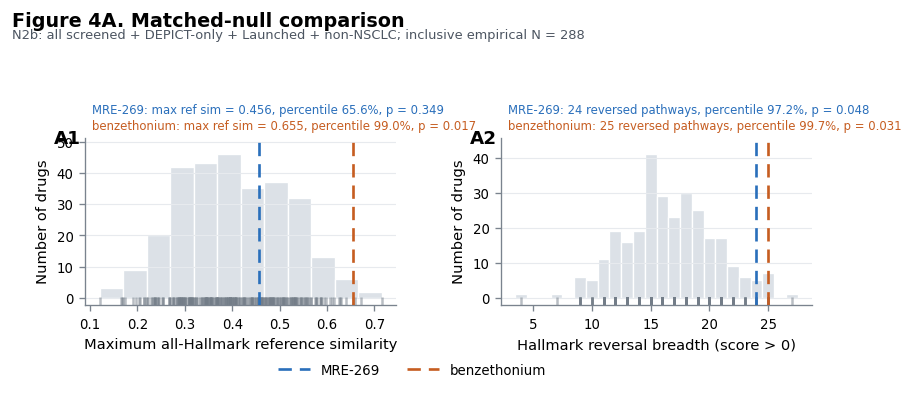

In [21]:
from matplotlib.lines import Line2D

FOCUS_CANDIDATE_COLORS = {
    normalize_drug_name("MRE-269"): "#2A6FBB",
    normalize_drug_name("benzethonium"): "#C65D21",
}


def _scientific_hist_bins(values, metric, requested_bins=18):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return requested_bins
    if metric == "hallmark_reversal_breadth":
        lo = int(np.floor(values.min()))
        hi = int(np.ceil(values.max()))
        return np.arange(lo - 0.5, hi + 1.5, 1.0)
    if values.size >= 8:
        q25, q75 = np.percentile(values, [25, 75])
        iqr = q75 - q25
        if iqr > 0:
            width = 2 * iqr / np.cbrt(values.size)
            if width > 0:
                n_bins = int(np.ceil((values.max() - values.min()) / width))
                return max(8, min(22, n_bins))
    return requested_bins


def _draw_matched_null_panel(
    ax,
    metrics_df,
    summary_df,
    metric,
    xlabel,
    panel_label,
    bins=18,
):
    vals = pd.to_numeric(metrics_df[metric], errors="coerce").dropna()
    if vals.empty:
        ax.text(0.5, 0.5, f"No values for {metric}", ha="center", va="center")
        ax.set_axis_off()
        return

    hist_bins = _scientific_hist_bins(vals.to_numpy(), metric, bins)
    counts, _, _ = ax.hist(
        vals,
        bins=hist_bins,
        color="#DCE1E7",
        edgecolor="white",
        linewidth=0.8,
        zorder=1,
    )

    rug_y = -max(float(np.max(counts)) * 0.025, 0.06)
    ax.scatter(
        vals,
        np.full(len(vals), rug_y),
        marker="|",
        s=25,
        color="#737D88",
        alpha=0.50,
        clip_on=False,
        zorder=2,
    )

    ax.set_xlabel(xlabel, fontsize=8.8)
    ax.set_ylabel("Number of drugs", fontsize=8.8)
    ax.text(
        -0.10,
        1.05,
        panel_label,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#7A838E")
    ax.grid(axis="y", color="#E7EAEE", linewidth=0.7, zorder=0)
    ax.tick_params(labelsize=8, color="#7A838E")

    candidate_rows = metrics_df[metrics_df["is_focus_candidate"]].sort_values("rank")
    ymax = max(ax.get_ylim()[1], 1.0)

    for i, (_, row) in enumerate(candidate_rows.iterrows()):
        x = row.get(metric, np.nan)
        if not np.isfinite(x):
            continue

        ckey = row["drug_key"]
        color = FOCUS_CANDIDATE_COLORS.get(ckey, "#4C78A8")
        ax.axvline(x, color=color, linestyle=(0, (5, 3)), linewidth=1.6, zorder=4)

        srow = summary_df[
            summary_df["candidate_key"].eq(ckey)
            & summary_df["metric"].eq(metric)
        ]
        if not srow.empty:
            srow = srow.iloc[0]
            if metric == "hallmark_reversal_breadth":
                value_text = f"{int(round(x))} reversed pathways"
            else:
                value_text = f"max ref sim = {x:.3f}"

            stat_text = (
                f"{row['pert_iname']}: {value_text}, "
                f"percentile {srow['inclusive_percentile_higher_is_better']:.1f}%, "
                f"p = {srow['inclusive_empirical_pvalue']:.3f}"
            )
        else:
            stat_text = f"{row['pert_iname']}"

        # Put the result summary in a dedicated annotation band above the axes,
        # so it never blocks the histogram bars.
        ax.text(
            0.02,
            1.13 - 0.10 * i,
            stat_text,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=7.0,
            color=color,
            clip_on=False,
            zorder=6,
        )

    ax.set_ylim(bottom=min(rug_y * 2.0, -0.20), top=ymax * 1.06)


def plot_figure4a_matched_null_combined(metrics_df, summary_df):
    # 7.5 × 3.4 in is compact enough for a two-column manuscript panel and easy to scale in Illustrator.
    fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.10))

    _draw_matched_null_panel(
        axes[0],
        metrics_df,
        summary_df,
        metric="max_nsclc_reference_similarity",
        xlabel="Maximum all-Hallmark reference similarity",
        panel_label="A1",
    )
    _draw_matched_null_panel(
        axes[1],
        metrics_df,
        summary_df,
        metric="hallmark_reversal_breadth",
        xlabel="Hallmark reversal breadth (score > 0)",
        panel_label="A2",
    )

    fig.suptitle(
        "Figure 4A. Matched-null comparison",
        x=0.01,
        ha="left",
        fontsize=11.5,
        fontweight="bold",
        y=1.01,
    )
    fig.text(
        0.01,
        0.965,
        f"{primary_null_label}; inclusive empirical N = {len(metrics_df)}",
        ha="left",
        va="top",
        fontsize=7.8,
        color="#4C5561",
    )

    legend_handles = [
        Line2D([0], [0], color=FOCUS_CANDIDATE_COLORS[normalize_drug_name("MRE-269")],
               lw=1.6, linestyle=(0, (5, 3)), label="MRE-269"),
        Line2D([0], [0], color=FOCUS_CANDIDATE_COLORS[normalize_drug_name("benzethonium")],
               lw=1.6, linestyle=(0, (5, 3)), label="benzethonium"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.005),
        ncol=2,
        frameon=False,
        fontsize=8,
        handlelength=2.4,
    )

    fig.subplots_adjust(left=0.10, right=0.99, bottom=0.22, top=0.67, wspace=0.34)
    save_figure(fig, "fig4a_matched_null_combined_two_panel")


plot_figure4a_matched_null_combined(
    matched_null_metrics,
    matched_null_candidate_summary,
)


## First plot
I think the first plot showed that the MRE-269 does not have a very similar NSCLC FDA-approved reference drug, but the benzethonium has;

## Second and third plot
However, both MRE-269 and benzethonium have a strong reversal score and broad reversal spectrum on hallmark pathways.


## 23. Bootstrap nearest-reference frequency analysis

This block resamples all Hallmark pathway columns with replacement 5,000 times. For each bootstrap sample, it recomputes Spearman similarity between each focus candidate and every FDA-approved NSCLC reference, then records which reference is selected as the nearest neighbor. This tests whether the observed nearest reference is stable or whether the candidate belongs to a broader therapeutic neighborhood.


In [22]:

def _spearman_array_safe(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan
    xv = x[mask]
    yv = y[mask]
    if np.nanstd(xv) == 0 or np.nanstd(yv) == 0:
        return np.nan
    rho, _ = spearmanr(xv, yv)
    return float(rho)


def bootstrap_nearest_reference_frequency(pathway_matrix, candidate_keys, b=5000, seed=20260711):
    """Bootstrap Hallmark pathway columns and record nearest FDA-approved NSCLC reference frequencies."""
    rng = np.random.default_rng(seed)
    columns = list(pathway_matrix.columns)
    m = len(columns)
    if m < 3:
        raise ValueError("Need at least 3 pathway columns for bootstrap Spearman analysis.")

    ref_rows = [idx for idx in pathway_matrix.index if idx[0] == "Observed LINCS"]
    candidate_rows = [idx for idx in pathway_matrix.index if idx[0] == "DEPICT-predicted LINCS" and idx[2] in set(candidate_keys)]
    if not ref_rows:
        raise ValueError("No observed FDA-approved NSCLC reference rows found in pathway matrix.")
    if not candidate_rows:
        raise ValueError("No focus candidate rows found in pathway matrix.")

    ref_mat = pathway_matrix.loc[ref_rows].to_numpy(dtype=float)
    ref_meta = pd.DataFrame([{
        "reference": idx[1],
        "reference_key": idx[2],
        "reference_rank": idx[3],
        "reference_reverse_score": idx[4],
        "reference_drug_group": idx[5],
    } for idx in ref_rows])

    observed_similarity_records = []
    bootstrap_records = []

    for cidx in candidate_rows:
        candidate = cidx[1]
        candidate_key = cidx[2]
        candidate_rank = cidx[3]
        candidate_reverse_score = cidx[4]
        cand_vec = pathway_matrix.loc[cidx].to_numpy(dtype=float)

        # Observed full-vector similarity.
        obs_sims = []
        for r_i, ridx in enumerate(ref_rows):
            rho = _spearman_array_safe(cand_vec, ref_mat[r_i, :])
            obs_sims.append(rho)
            observed_similarity_records.append({
                "candidate": candidate,
                "candidate_key": candidate_key,
                "candidate_rank": candidate_rank,
                "candidate_reverse_score": candidate_reverse_score,
                "reference": ridx[1],
                "reference_key": ridx[2],
                "reference_rank": ridx[3],
                "reference_reverse_score": ridx[4],
                "observed_similarity": rho,
                "n_hallmark_pathways": m,
            })
        obs_sims_arr = np.asarray(obs_sims, dtype=float)
        if np.all(~np.isfinite(obs_sims_arr)):
            observed_nearest_key = np.nan
            observed_nearest = np.nan
            observed_nearest_similarity = np.nan
        else:
            best_i = int(np.nanargmax(obs_sims_arr))
            observed_nearest_key = ref_rows[best_i][2]
            observed_nearest = ref_rows[best_i][1]
            observed_nearest_similarity = obs_sims_arr[best_i]

        nearest_keys = []
        nearest_names = []
        nearest_sims = []
        for boot_i in range(b):
            sampled_cols = rng.integers(0, m, size=m)
            c_sample = cand_vec[sampled_cols]
            sims = np.array([_spearman_array_safe(c_sample, ref_mat[r_i, sampled_cols]) for r_i in range(len(ref_rows))], dtype=float)
            if np.all(~np.isfinite(sims)):
                nearest_keys.append(np.nan)
                nearest_names.append(np.nan)
                nearest_sims.append(np.nan)
                continue
            best_i = int(np.nanargmax(sims))
            nearest_keys.append(ref_rows[best_i][2])
            nearest_names.append(ref_rows[best_i][1])
            nearest_sims.append(sims[best_i])

        freq = (
            pd.DataFrame({
                "nearest_reference": nearest_names,
                "nearest_reference_key": nearest_keys,
                "bootstrap_max_similarity": nearest_sims,
            })
            .dropna(subset=["nearest_reference_key"])
            .groupby(["nearest_reference", "nearest_reference_key"], as_index=False)
            .agg(
                bootstrap_nearest_count=("nearest_reference_key", "size"),
                bootstrap_max_similarity_mean=("bootstrap_max_similarity", "mean"),
                bootstrap_max_similarity_median=("bootstrap_max_similarity", "median"),
            )
        )
        freq["bootstrap_B"] = b
        freq["bootstrap_nearest_frequency"] = freq["bootstrap_nearest_count"] / b
        freq["candidate"] = candidate
        freq["candidate_key"] = candidate_key
        freq["candidate_rank"] = candidate_rank
        freq["candidate_reverse_score"] = candidate_reverse_score
        freq["observed_nearest_reference"] = observed_nearest
        freq["observed_nearest_reference_key"] = observed_nearest_key
        freq["observed_nearest_similarity"] = observed_nearest_similarity
        freq["is_observed_nearest_reference"] = freq["nearest_reference_key"].eq(observed_nearest_key)
        bootstrap_records.append(freq)

    observed_similarity_df = pd.DataFrame(observed_similarity_records)
    if not observed_similarity_df.empty:
        observed_similarity_df = observed_similarity_df.sort_values(
            ["candidate_rank", "observed_similarity"], ascending=[True, False]
        )
    bootstrap_frequency_df = pd.concat(bootstrap_records, ignore_index=True, sort=False) if bootstrap_records else pd.DataFrame()
    if not bootstrap_frequency_df.empty:
        bootstrap_frequency_df = bootstrap_frequency_df.sort_values(
            ["candidate_rank", "bootstrap_nearest_frequency"], ascending=[True, False]
        )
    return observed_similarity_df, bootstrap_frequency_df


bootstrap_observed_similarity, bootstrap_reference_frequency = bootstrap_nearest_reference_frequency(
    all_hallmark_wide,
    candidate_keys=BOOTSTRAP_CANDIDATE_KEYS,
    b=BOOTSTRAP_B,
    seed=BOOTSTRAP_RANDOM_SEED,
)

bootstrap_observed_similarity.to_csv(TABLE_DIR / "fig4_bootstrap_observed_all_reference_similarity_all_hallmark.csv", index=False)
bootstrap_reference_frequency.to_csv(TABLE_DIR / "fig4_bootstrap_nearest_reference_frequency_all_hallmark.csv", index=False)

show_df(bootstrap_observed_similarity, "Observed all-Hallmark similarity between focus candidates and references", 100)
show_df(bootstrap_reference_frequency, "Bootstrap nearest-reference frequency", 100)

# Candidate-level stability summary.
bootstrap_stability_summary = (
    bootstrap_reference_frequency
    .sort_values(["candidate_rank", "bootstrap_nearest_frequency"], ascending=[True, False])
    .groupby(["candidate", "candidate_key", "candidate_rank", "observed_nearest_reference", "observed_nearest_similarity"], as_index=False)
    .agg(
        top_bootstrap_reference=("nearest_reference", "first"),
        top_bootstrap_frequency=("bootstrap_nearest_frequency", "first"),
        observed_nearest_bootstrap_frequency=("bootstrap_nearest_frequency", lambda x: np.nan),
        n_references_ge_1pct=("bootstrap_nearest_frequency", lambda x: int((x >= 0.01).sum())),
        n_references_ge_5pct=("bootstrap_nearest_frequency", lambda x: int((x >= 0.05).sum())),
    )
)
# Fill observed-nearest bootstrap frequency explicitly.
obs_freq_records = []
for _, row in bootstrap_reference_frequency.iterrows():
    if row.get("is_observed_nearest_reference", False):
        obs_freq_records.append({
            "candidate_key": row["candidate_key"],
            "observed_nearest_bootstrap_frequency": row["bootstrap_nearest_frequency"],
        })
obs_freq_df = pd.DataFrame(obs_freq_records).drop_duplicates("candidate_key") if obs_freq_records else pd.DataFrame(columns=["candidate_key", "observed_nearest_bootstrap_frequency"])
bootstrap_stability_summary = bootstrap_stability_summary.drop(columns=["observed_nearest_bootstrap_frequency"]).merge(obs_freq_df, on="candidate_key", how="left")
bootstrap_stability_summary.to_csv(TABLE_DIR / "fig4_bootstrap_nearest_reference_stability_summary.csv", index=False)
show_df(bootstrap_stability_summary, "Bootstrap nearest-reference stability summary", 20)



Observed all-Hallmark similarity between focus candidates and references
------------------------------------------------------------------------


,candidate,candidate_key,candidate_rank,candidate_reverse_score,reference,reference_key,reference_rank,reference_reverse_score,observed_similarity,n_hallmark_pathways
2,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,15,0.706004,0.456379,34
10,MRE-269,mre269,18,0.713321,methotrexate,methotrexate,2756,0.309387,0.416043,34
8,MRE-269,mre269,18,0.713321,gefitinib,gefitinib,30,0.666454,0.365928,34
14,MRE-269,mre269,18,0.713321,vinorelbine,vinorelbine,592,0.417239,0.295951,34
7,MRE-269,mre269,18,0.713321,everolimus,everolimus,573,0.420379,0.293812,34
0,MRE-269,mre269,18,0.713321,afatinib,afatinib,310,0.479281,0.273950,34
9,MRE-269,mre269,18,0.713321,gemcitabine,gemcitabine,171,0.533687,0.231780,34
6,MRE-269,mre269,18,0.713321,erlotinib,erlotinib,1942,0.330656,0.169137,34
1,MRE-269,mre269,18,0.713321,cisplatin,cisplatin,982,0.374543,0.156608,34
13,MRE-269,mre269,18,0.713321,trametinib,trametinib,57,0.628831,0.126967,34


shape: (30, 10)

Bootstrap nearest-reference frequency
-------------------------------------


,nearest_reference,nearest_reference_key,bootstrap_nearest_count,bootstrap_max_similarity_mean,bootstrap_max_similarity_median,bootstrap_B,bootstrap_nearest_frequency,candidate,candidate_key,candidate_rank,candidate_reverse_score,observed_nearest_reference,observed_nearest_reference_key,observed_nearest_similarity,is_observed_nearest_reference
2,crizotinib,crizotinib,1751,0.582717,0.584280,5000,0.3502,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,True
9,methotrexate,methotrexate,1088,0.567750,0.565725,5000,0.2176,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False
7,gefitinib,gefitinib,889,0.555207,0.553749,5000,0.1778,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False
13,vinorelbine,vinorelbine,398,0.511896,0.512222,5000,0.0796,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False
6,everolimus,everolimus,290,0.508132,0.512751,5000,0.0580,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False
0,afatinib,afatinib,187,0.579793,0.582401,5000,0.0374,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False
8,gemcitabine,gemcitabine,107,0.481333,0.480687,5000,0.0214,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False
5,erlotinib,erlotinib,92,0.492999,0.499386,5000,0.0184,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False
12,trametinib,trametinib,74,0.505062,0.504802,5000,0.0148,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False
1,cisplatin,cisplatin,66,0.480927,0.485741,5000,0.0132,MRE-269,mre269,18,0.713321,crizotinib,crizotinib,0.456379,False


shape: (25, 15)

Bootstrap nearest-reference stability summary
---------------------------------------------


,candidate,candidate_key,candidate_rank,observed_nearest_reference,observed_nearest_similarity,top_bootstrap_reference,top_bootstrap_frequency,n_references_ge_1pct,n_references_ge_5pct,observed_nearest_bootstrap_frequency
0,MRE-269,mre269,18,crizotinib,0.456379,crizotinib,0.3502,10,5,0.3502
1,benzethonium,benzethonium,42,gemcitabine,0.654698,gemcitabine,0.5466,5,4,0.5466


shape: (2, 10)


## 24. Plot Figure 4B — cumulative bootstrap nearest-reference composition

This block combines MRE-269 and benzethonium in one compact 100% stacked horizontal bar plot. Reference drugs are ordered by bootstrap nearest-reference frequency, retained through the segment that first reaches 95% cumulative frequency, and the remaining frequency is grouped as `Other`. The dashed line marks the 95% threshold.


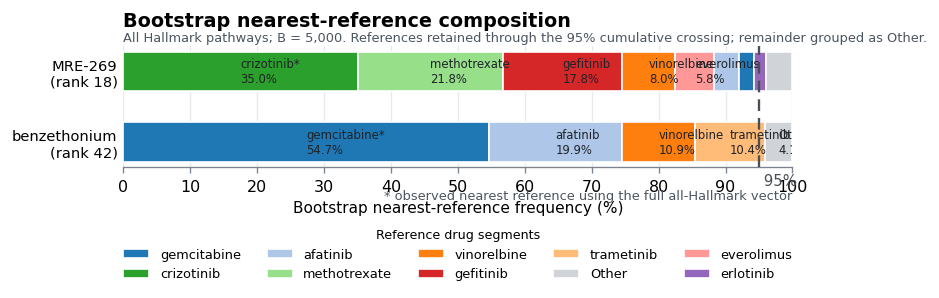


Cumulative bootstrap stacked-bar segments
-----------------------------------------


,candidate,candidate_key,candidate_rank,segment,frequency,is_other,is_observed_nearest_reference
0,benzethonium,benzethonium,42,gemcitabine,0.5466,False,True
1,benzethonium,benzethonium,42,afatinib,0.1992,False,False
2,benzethonium,benzethonium,42,vinorelbine,0.1086,False,False
3,benzethonium,benzethonium,42,trametinib,0.1044,False,False
4,benzethonium,benzethonium,42,Other,0.0412,True,False
5,MRE-269,mre269,18,crizotinib,0.3502,False,True
6,MRE-269,mre269,18,methotrexate,0.2176,False,False
7,MRE-269,mre269,18,gefitinib,0.1778,False,False
8,MRE-269,mre269,18,vinorelbine,0.0796,False,False
9,MRE-269,mre269,18,everolimus,0.0580,False,False


shape: (14, 7)


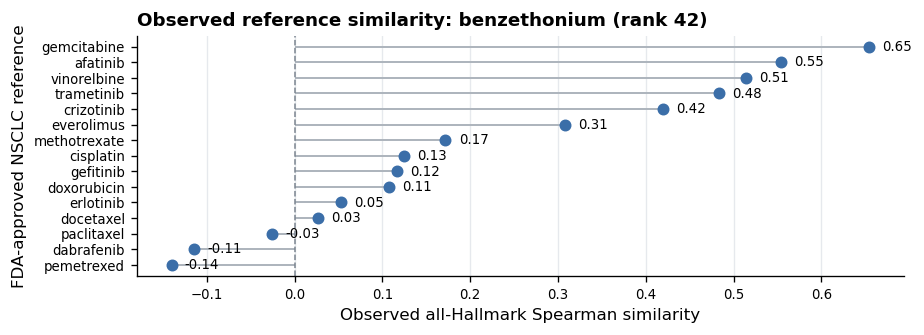

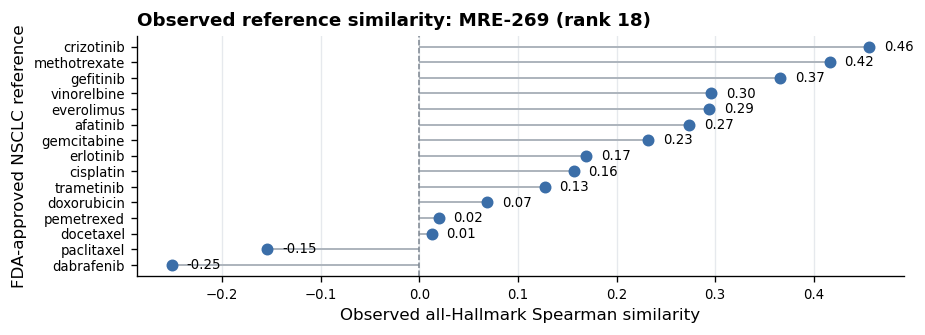

In [23]:
from matplotlib.patches import Patch


def build_cumulative_frequency_segments(freq_df, candidate_key, cumulative_cutoff=0.95):
    """Keep ordered reference segments through the 95% crossing; aggregate the remainder as Other."""
    df = freq_df[freq_df["candidate_key"].eq(candidate_key)].copy()
    if df.empty:
        return pd.DataFrame()

    df = df.sort_values("bootstrap_nearest_frequency", ascending=False).reset_index(drop=True)
    df["cumulative_frequency"] = df["bootstrap_nearest_frequency"].cumsum()

    crossing = np.flatnonzero(df["cumulative_frequency"].to_numpy() >= cumulative_cutoff)
    keep_end = int(crossing[0]) if len(crossing) else len(df) - 1
    kept = df.iloc[: keep_end + 1].copy()
    remainder = float(df.iloc[keep_end + 1:]["bootstrap_nearest_frequency"].sum())

    records = []
    for _, row in kept.iterrows():
        records.append({
            "candidate": row["candidate"],
            "candidate_key": row["candidate_key"],
            "candidate_rank": row["candidate_rank"],
            "segment": row["nearest_reference"],
            "frequency": float(row["bootstrap_nearest_frequency"]),
            "is_other": False,
            "is_observed_nearest_reference": bool(row.get("is_observed_nearest_reference", False)),
        })
    if remainder > 0:
        first = df.iloc[0]
        records.append({
            "candidate": first["candidate"],
            "candidate_key": first["candidate_key"],
            "candidate_rank": first["candidate_rank"],
            "segment": "Other",
            "frequency": remainder,
            "is_other": True,
            "is_observed_nearest_reference": False,
        })
    out = pd.DataFrame(records)
    # Numerical safeguard so the plotted bar closes exactly at 100%.
    if not out.empty:
        total = out["frequency"].sum()
        if total > 0:
            out["frequency"] = out["frequency"] / total
    return out


def plot_cumulative_bootstrap_stacked_bar(freq_df, candidate_keys, cumulative_cutoff=0.95):
    segment_frames = [
        build_cumulative_frequency_segments(freq_df, key, cumulative_cutoff=cumulative_cutoff)
        for key in candidate_keys
    ]
    segments = pd.concat([x for x in segment_frames if not x.empty], ignore_index=True)
    if segments.empty:
        print("No bootstrap nearest-reference frequencies available for cumulative stacked plot.")
        return

    # Stable color mapping across both candidate bars.
    references = [x for x in segments["segment"].drop_duplicates().tolist() if x != "Other"]
    cmap = plt.get_cmap("tab20")
    reference_colors = {ref: cmap(i % 20) for i, ref in enumerate(references)}
    reference_colors["Other"] = "#D0D3D8"

    candidate_order = (
        segments[["candidate", "candidate_key", "candidate_rank"]]
        .drop_duplicates()
        .sort_values("candidate_rank")
    )

    fig, ax = plt.subplots(figsize=(6.8, 3.25))
    y_positions = np.arange(len(candidate_order))
    bar_height = 0.56

    for y, (_, cand) in zip(y_positions, candidate_order.iterrows()):
        cdf = segments[segments["candidate_key"].eq(cand["candidate_key"])].copy()
        left = 0.0
        for _, row in cdf.iterrows():
            width = row["frequency"] * 100.0
            color = reference_colors[row["segment"]]
            ax.barh(
                y,
                width,
                left=left,
                height=bar_height,
                color=color,
                edgecolor="white",
                linewidth=1.0,
                zorder=2,
            )

            # Directly label readable segments; observed nearest gets a star.
            if width >= 4.0:
                star = "*" if row["is_observed_nearest_reference"] else ""
                label = f"{row['segment']}{star}\n{width:.1f}%"
                ax.text(
                    left + width / 2,
                    y,
                    label,
                    ha="left",
                    va="center",
                    fontsize=7.0,
                    color="#1F2328",
                    clip_on=True,
                    zorder=3,
                )
            left += width

    ax.axvline(
        cumulative_cutoff * 100,
        color="#4A4F55",
        linestyle=(0, (5, 3)),
        linewidth=1.4,
        zorder=4,
    )
    ax.text(
        cumulative_cutoff * 100,
        len(candidate_order) - 0.34,
        f" {int(cumulative_cutoff * 100)}%",
        ha="left",
        va="bottom",
        fontsize=9,
        color="#4A4F55",
    )

    y_labels = []
    for _, cand in candidate_order.iterrows():
        rank_text = f"rank {int(cand['candidate_rank'])}" if pd.notna(cand["candidate_rank"]) else "rank NA"
        y_labels.append(f"{cand['candidate']}\n({rank_text})")
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=8.8)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 10))
    ax.set_xlabel("Bootstrap nearest-reference frequency (%)", fontsize=9.2)
    ax.set_title(
        "Bootstrap nearest-reference composition",
        loc="left",
        fontsize=11.5,
        fontweight="bold",
        pad=12,
    )
    ax.text(
        0.0,
        1.015,
        f"All Hallmark pathways; B = {BOOTSTRAP_B:,}. References retained through the 95% cumulative crossing; remainder grouped as Other.",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=7.8,
        color="#4C5561",
    )

    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#7A838E")
    ax.grid(axis="x", color="#E6E9ED", linewidth=0.8, zorder=0)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=9.5, color="#7A838E")

    # Compact legend underneath; the star marks the full-vector observed nearest reference.
    present_segments = segments.groupby("segment", sort=False)["frequency"].sum().sort_values(ascending=False).index.tolist()
    handles = [Patch(facecolor=reference_colors[s], edgecolor="white", label=s) for s in present_segments]
    ax.legend(
        handles=handles,
        title="Reference drug segments",
        frameon=False,
        fontsize=7.8,
        title_fontsize=7.6,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.42),
        ncol=min(5, max(2, len(handles))),
    )
    ax.text(
        1.0,
        -0.18,
        "* observed nearest reference using the full all-Hallmark vector",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=7.8,
        color="#4C5561",
    )

    fig.subplots_adjust(left=0.17, right=0.99, bottom=0.43, top=0.74)
    save_figure(fig, "fig4b_bootstrap_nearest_reference_cumulative_stacked_95pct")

    segments.to_csv(
        TABLE_DIR / "fig4_bootstrap_nearest_reference_cumulative_stacked_segments.csv",
        index=False,
    )
    show_df(segments, "Cumulative bootstrap stacked-bar segments", 100)


def plot_observed_similarity_lollipop(obs_df, candidate_key, top_n=None):
    """Supplementary diagnostic retained from the prior notebook."""
    df = obs_df[obs_df["candidate_key"].eq(candidate_key)].copy()
    if df.empty:
        print(f"No observed similarity data for candidate key: {candidate_key}")
        return
    df = df.sort_values("observed_similarity", ascending=False)
    cand_name = df["candidate"].iloc[0]
    cand_rank = int(df["candidate_rank"].iloc[0]) if pd.notna(df["candidate_rank"].iloc[0]) else "NA"
    if top_n is not None:
        df = df.head(top_n).copy()
    df = df.sort_values("observed_similarity", ascending=True)

    fig_height = max(3.2, 0.35 * len(df) + 1.2)
    fig, ax = plt.subplots(figsize=(7.8, fig_height))
    y = np.arange(len(df))
    ax.hlines(y, 0, df["observed_similarity"], color="#AEB5BD", linewidth=1.2)
    ax.scatter(df["observed_similarity"], y, s=38, color="#3B6EA8", zorder=3)
    ax.axvline(0, color="#7A838E", linestyle="--", linewidth=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(df["reference"])
    ax.set_xlabel("Observed all-Hallmark Spearman similarity")
    ax.set_ylabel("FDA-approved NSCLC reference")
    ax.set_title(f"Observed reference similarity: {cand_name} (rank {cand_rank})", loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#E6E9ED", linewidth=0.8)
    for yi, val in zip(y, df["observed_similarity"]):
        ax.text(val + 0.015, yi, f"{val:.2f}", va="center", fontsize=8)
    fig.subplots_adjust(left=0.17, right=0.99, bottom=0.43, top=0.74)
    safe_name = re.sub(r"[^A-Za-z0-9]+", "_", cand_name).strip("_").lower()
    save_figure(fig, f"fig4_observed_reference_similarity_lollipop_{safe_name}")


plot_cumulative_bootstrap_stacked_bar(
    bootstrap_reference_frequency,
    candidate_keys=sorted(BOOTSTRAP_CANDIDATE_KEYS),
    cumulative_cutoff=0.95,
)

# Keep observed-similarity rankings as supplementary diagnostics.
for cand_key in sorted(BOOTSTRAP_CANDIDATE_KEYS):
    plot_observed_similarity_lollipop(
        bootstrap_observed_similarity,
        cand_key,
        top_n=None,
    )


## 25. Figure 4A–C output summary

This block prints the key output files for the final matched-null, bootstrap-composition, and focused pathway-reversal panels.


In [24]:
matched_null_outputs = [
    "fig4b_matched_null_universe_size_summary.csv",
    "fig4b_matched_null_candidate_metrics_all_hallmark.csv",
    "fig4b_matched_null_candidate_empirical_pvalues.csv",
    "fig4_bootstrap_nearest_reference_frequency_all_hallmark.csv",
    "fig4_bootstrap_nearest_reference_stability_summary.csv",
    "fig4_bootstrap_nearest_reference_cumulative_stacked_segments.csv",
]
print("\nKey matched-null/bootstrap tables:")
for name in matched_null_outputs:
    p = TABLE_DIR / name
    print(" -", p, "exists=" + str(p.exists()))

print("\nKey matched-null/bootstrap figures:")
figure_patterns = [
    "fig4b_matched_null*_polished.pdf",
    "fig4b_bootstrap_nearest_reference_cumulative_stacked_95pct.pdf",
    "fig4_observed_reference_similarity_lollipop*.pdf",
]
for pattern in figure_patterns:
    for p in sorted(FIG_DIR.glob(pattern)):
        print(" -", p)



Key matched-null/bootstrap tables:
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/tables/fig4b_matched_null_universe_size_summary.csv exists=True
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/tables/fig4b_matched_null_candidate_metrics_all_hallmark.csv exists=True
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/tables/fig4b_matched_null_candidate_empirical_pvalues.csv exists=True
 - /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/Figure4_MRE269_Benzethonium_repurposing/tables/fig4_bootstrap_nearest_reference_frequency_all_hallmark.csv exists=True
 - /wo